# Study of the latent representations

## *Experiences description*

### Experiment 3 - Autoencoders Trained on Increasing Climate Diversity

In this third experiment, we want to study the distribution shift of our data across climates inside an autoencoder (AE). So we focus on the latent representation of an AE trained on some climates.

We retrieve the patchs used in the second experiment. We randomly split these samples in train/val/test datasets for each climate.
We then train the AE on one of these configurations (using the train and validation sets) :
- historical climate
- historical and ssp245 climates
- historical, ssp245 and ssp370 climates
- all climates

Then we evaluate the reconstruction quality of the AE on all climates (using the test sets)

We then project the latent representations of the test sets into a common PCA space, and we plot some visualization of this PCA space. 

And finally we perform the same analyzes between distributions then in the second experiment : 
- compute multivariate shift metrics in that latent PCA space;
- analyze the moments of the latent principal components;
- analyze extreme latent scores;
- analyze seasonal shifts in latent PCA space.

### Experiment 4 - Invariant Autoencoder with Latent Alignment

In this fourth experiment, we dive a step closer to the real CERA architecture by adding an explicit climate invariance term to the autoencoder loss.

The idea is to test wether adding an alignment loss between climates will effectivelly bring different climate distributions closer compared to the raw data and to the simple AE architecture. Here we only train the AE on the historical climate and on SSP245 to reproduce the CERA architecture (one "cold" and one "warm" climate).

Training set:
- **historical + ssp245**

Loss:
- reconstruction loss on all samples;
- alignment loss between latent samples from **historical** and **ssp245**.

Loss equation : 
$$
L = L_{\text{rec}} + \lambda_{\text{Align}} \cdot \text{Align}(Z^{\text{hist}}_{\text{align}}, Z^{\text{ssp245}}_{\text{align}})
$$

Alignment method : 

Here we consider two different method to align the historical and SSP245 climates ;
- We consider a sliced Wasserstein alignment loss 
- And a adversarial classifier.

Note that in CERA, the method used is Earth Mover's Distance (EMD), but EMD can be expensive in high dimension, it is why we use a sliced Wasserstein alignment loss, which is a practical EMD-style approximation.

Interpretation:
- decreasing the alignment term should reduce latent distribution shift between historical and ssp245, and potentially between historical and other warmer climates;
- this must be balanced against reconstruction quality;
- PCA visualizations help determine whether the latent clouds become more mixed and allow us to calculate the same metrics as before onto our "normalized" PCA space.

### Experiment 5 - CERA-like architecture

In this fifth experiment, we add a predictor to the architecture considered in the fourth experiment. We thus now consider : AE (constructed either with cnn2D or MLPs) (and with either sliced wasserstein distance alignment or adversarial classifier alignment) and a predictor using only the aligned part of the historical climate latent representations. The predictor needs to predict the precipitation field (pr) over the whole grid of the samples. This architecture will be called a CERA-like architecture.

The same test/train/val split than before is used.

This CERA-like setup extends the invariant AE by adding a precipitation predictor:
- AE input: multivariate samples from historical + ssp245 climates.
- AE losses: reconstruction + latent alignment on the first 48 latent dimensions.
- Predictor: MLP on aligned latent dimensions (historical only) to predict `pr` over all 70 patch points.

Global loss used for AE update:
$$
L_{AE} = L_{rec} + \lambda_{align} L_{align} + \lambda_{pred} L_{pred}
$$

And we perform the predictor update at the same time, to be consistent with the end to end training used in the original CERA architecture.

## Part 0 - Global Configuration

**Library import**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.path as mpath
from matplotlib.patches import PathPatch
from scipy import stats
from scipy.stats import wasserstein_distance, ks_2samp
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from matplotlib.colors import to_rgba
from IPython.display import display
from cycler import cycler
import seaborn as sns
import json
from pathlib import Path
import pickle
from collections import OrderedDict
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

**Data Loading**

Chosen variables :

In [ ]:
num_sample = 1000000
chosen_autoencoder_type = "CNN" # choose between "MLP" and "CNN"
inv_alignment_method = "swd" # choose between "swd" and "adversarial"
variable = "pr" # variable to predict
val_fraction = 0.05
test_fraction = 0.15
cera_lambda_align = 0.0001
cera_lambda_pred = 0.01

In [3]:
precomputed_dir = Path(f"/glade/derecho/scratch/tsalin/CMIP/derived/multivariate_samples_optimized_NGS_v1000")
if not precomputed_dir.exists():
    raise FileNotFoundError(f"Precomputed data directory not found: {precomputed_dir}")

with open(precomputed_dir / "run_config.json", "r", encoding="utf-8") as f:
    run_cfg = json.load(f)

climate_order = list(run_cfg["climate_order"])
climate_colors = dict(run_cfg["climate_colors"])
selected_variables_full = list(run_cfg["selected_variables"])
max_abs_lat = float(run_cfg["max_abs_lat"])
patch_size_km = float(run_cfg["patch_size_km"])
time_stride = int(run_cfg["time_stride"])
max_samples_per_climate = int(run_cfg["max_samples_per_climate"])
random_seed = int(run_cfg["random_seed"])
n_lat = int(run_cfg["n_lat"])
n_lon = int(run_cfg["n_lon"])
grid_points_per_patch = int(run_cfg["grid_points_per_patch"])
n_patches = int(run_cfg["n_patches"])

In [4]:
# Here we import the latent representations for the chosen variables

latent_root = Path("/glade/work/tsalin/CMIP/latent_representations")
if not latent_root.exists():
    raise FileNotFoundError(f"Latent representations directory not found: {latent_root}")

def _load_latent_payload(file_path):
    if not file_path.exists():
        raise FileNotFoundError(f"Latent representations file not found: {file_path}")

    with open(file_path, "rb") as handle:
        payload = pickle.load(handle)

    latent_by_climate = {}
    metadata_by_climate = {}
    for climate, entry in payload.items():
        if "latent" not in entry:
            raise KeyError(f"Missing 'latent' entry for climate '{climate}' in {file_path}")
        latent_by_climate[climate] = np.asarray(entry["latent"])
        metadata_by_climate[climate] = pd.DataFrame(entry["metadata"]).reset_index(drop=True)

    return latent_by_climate, metadata_by_climate


# ── exp3 ──────────────────────────────────────────────────────────────────────
_exp3_latent_dir = latent_root / "latent_representations_exp_3"

exp3_latent_file_AEh     = _exp3_latent_dir / f"exp3_ns{num_sample}_{chosen_autoencoder_type}_AEh_{variable}_{val_fraction}_{test_fraction}_latent_representations_df.pkl"
exp3_latent_file_AEhs2   = _exp3_latent_dir / f"exp3_ns{num_sample}_{chosen_autoencoder_type}_AEhs2_{variable}_{val_fraction}_{test_fraction}_latent_representations_df.pkl"
exp3_latent_file_AEhs2s3 = _exp3_latent_dir / f"exp3_ns{num_sample}_{chosen_autoencoder_type}_AEhs2s3_{variable}_{val_fraction}_{test_fraction}_latent_representations_df.pkl"
exp3_latent_file_AEall   = _exp3_latent_dir / f"exp3_ns{num_sample}_{chosen_autoencoder_type}_AEall_{variable}_{val_fraction}_{test_fraction}_latent_representations_df.pkl"

# ── exp4 ──────────────────────────────────────────────────────────────────────
exp4_latent_file = latent_root / "latent_representations_exp_4" / f"exp4_ns{num_sample}_{chosen_autoencoder_type}_{inv_alignment_method}_{variable}_{val_fraction}_{test_fraction}_{cera_lambda_align}_latent_representations_df.pkl"

# ── exp5 ──────────────────────────────────────────────────────────────────────
_exp5_latent_dir = latent_root / "latent_representations_exp_5"

exp5_cera_latent_file           = _exp5_latent_dir / f"cera_ns{num_sample}_{chosen_autoencoder_type}_{inv_alignment_method}_{variable}_{val_fraction}_{test_fraction}_{cera_lambda_align}_{cera_lambda_pred}_latent_representations_df.pkl"
exp5_cera_full_latent_file      = _exp5_latent_dir / f"cera_full_latent_ns{num_sample}_{chosen_autoencoder_type}_{inv_alignment_method}_{variable}_{val_fraction}_{test_fraction}_{cera_lambda_align}_{cera_lambda_pred}_latent_representations_df.pkl"
exp5_baseline2_latent_file      = _exp5_latent_dir / f"baseline_CERA_noalign_ns{num_sample}_{chosen_autoencoder_type}_{variable}_{val_fraction}_{test_fraction}_{cera_lambda_pred}_latent_representations_df.pkl"
exp5_baseline_climax_latent_file = _exp5_latent_dir / f"baseline_ClimaX_ns{num_sample}_{variable}_{val_fraction}_{test_fraction}_latent_representations_df.pkl"
exp5_cera_swdn_latent_file      = _exp5_latent_dir / f"cera_ns{num_sample}_{chosen_autoencoder_type}_swdn_{variable}_{val_fraction}_{test_fraction}_0.85_0.1_latent_representations_df.pkl"

exp3_latent_test_by_climate_AEh,     exp3_latent_test_metadata_by_climate_AEh     = _load_latent_payload(exp3_latent_file_AEh)
exp3_latent_test_by_climate_AEhs2,   exp3_latent_test_metadata_by_climate_AEhs2   = _load_latent_payload(exp3_latent_file_AEhs2)
exp3_latent_test_by_climate_AEhs2s3, exp3_latent_test_metadata_by_climate_AEhs2s3 = _load_latent_payload(exp3_latent_file_AEhs2s3)
exp3_latent_test_by_climate_AEall,   exp3_latent_test_metadata_by_climate_AEall   = _load_latent_payload(exp3_latent_file_AEall)
exp4_latent_test_by_climate,         exp4_latent_test_metadata_by_climate         = _load_latent_payload(exp4_latent_file)
exp5_cera_latent_test_by_climate,         exp5_cera_latent_test_metadata_by_climate         = _load_latent_payload(exp5_cera_latent_file)
exp5_cera_full_latent_test_by_climate,    exp5_cera_full_latent_test_metadata_by_climate    = _load_latent_payload(exp5_cera_full_latent_file)
exp5_baseline2_latent_test_by_climate,    exp5_baseline2_latent_test_metadata_by_climate    = _load_latent_payload(exp5_baseline2_latent_file)
exp5_baseline_climax_latent_test_by_climate, exp5_baseline_climax_latent_test_metadata_by_climate = _load_latent_payload(exp5_baseline_climax_latent_file)
exp5_cera_swdn_latent_test_by_climate,    exp5_cera_swdn_latent_test_metadata_by_climate    = _load_latent_payload(exp5_cera_swdn_latent_file)

latent_test_sets = {
    "exp3_AEh": {
        "latent_test_by_climate": exp3_latent_test_by_climate_AEh,
        "latent_test_metadata_by_climate": exp3_latent_test_metadata_by_climate_AEh,
        "latent_file": exp3_latent_file_AEh,
    },
    "exp3_AEhs2": {
        "latent_test_by_climate": exp3_latent_test_by_climate_AEhs2,
        "latent_test_metadata_by_climate": exp3_latent_test_metadata_by_climate_AEhs2,
        "latent_file": exp3_latent_file_AEhs2,
    },
    "exp3_AEhs2s3": {
        "latent_test_by_climate": exp3_latent_test_by_climate_AEhs2s3,
        "latent_test_metadata_by_climate": exp3_latent_test_metadata_by_climate_AEhs2s3,
        "latent_file": exp3_latent_file_AEhs2s3,
    },
    "exp3_AEall": {
        "latent_test_by_climate": exp3_latent_test_by_climate_AEall,
        "latent_test_metadata_by_climate": exp3_latent_test_metadata_by_climate_AEall,
        "latent_file": exp3_latent_file_AEall,
    },
    "exp4": {
        "latent_test_by_climate": exp4_latent_test_by_climate,
        "latent_test_metadata_by_climate": exp4_latent_test_metadata_by_climate,
        "latent_file": exp4_latent_file,
    },
    "exp5_cera": {
        "latent_test_by_climate": exp5_cera_latent_test_by_climate,
        "latent_test_metadata_by_climate": exp5_cera_latent_test_metadata_by_climate,
        "latent_file": exp5_cera_latent_file,
    },
    "exp5_cera_full_latent": {
        "latent_test_by_climate": exp5_cera_full_latent_test_by_climate,
        "latent_test_metadata_by_climate": exp5_cera_full_latent_test_metadata_by_climate,
        "latent_file": exp5_cera_full_latent_file,
    },
    "exp5_baseline2": {
        "latent_test_by_climate": exp5_baseline2_latent_test_by_climate,
        "latent_test_metadata_by_climate": exp5_baseline2_latent_test_metadata_by_climate,
        "latent_file": exp5_baseline2_latent_file,
    },
    "exp5_baseline_climax": {
        "latent_test_by_climate": exp5_baseline_climax_latent_test_by_climate,
        "latent_test_metadata_by_climate": exp5_baseline_climax_latent_test_metadata_by_climate,
        "latent_file": exp5_baseline_climax_latent_file,
    },
    "exp5_cera_swdn": {
        "latent_test_by_climate": exp5_cera_swdn_latent_test_by_climate,
        "latent_test_metadata_by_climate": exp5_cera_swdn_latent_test_metadata_by_climate,
        "latent_file": exp5_cera_swdn_latent_file,
    }
}

print("Loaded latent representations:")
for latent_name, latent_payload in latent_test_sets.items():
    print(f"  {latent_name}: {latent_payload['latent_file']}")


Loaded latent representations:
  exp3_AEh: /glade/work/tsalin/CMIP/latent_representations/latent_representations_exp_3/exp3_ns2500000_CNN_AEh_pr_0.05_0.15_latent_representations_df.pkl
  exp3_AEhs2: /glade/work/tsalin/CMIP/latent_representations/latent_representations_exp_3/exp3_ns2500000_CNN_AEhs2_pr_0.05_0.15_latent_representations_df.pkl
  exp3_AEhs2s3: /glade/work/tsalin/CMIP/latent_representations/latent_representations_exp_3/exp3_ns2500000_CNN_AEhs2s3_pr_0.05_0.15_latent_representations_df.pkl
  exp3_AEall: /glade/work/tsalin/CMIP/latent_representations/latent_representations_exp_3/exp3_ns2500000_CNN_AEall_pr_0.05_0.15_latent_representations_df.pkl
  exp4: /glade/work/tsalin/CMIP/latent_representations/latent_representations_exp_4/exp4_ns2500000_CNN_swd_pr_0.05_0.15_0.45_latent_representations_df.pkl
  exp5_cera: /glade/work/tsalin/CMIP/latent_representations/latent_representations_exp_5/cera_ns2500000_CNN_swd_pr_0.05_0.15_0.45_0.1_latent_representations_df.pkl
  exp5_cera_full_l

## Part 1 - Study of the effective rank

In [ ]:
# Registry of the 16 setups. "slice" controls which latent dimensions are used:
#   None      -> all dimensions (full latent)
#   "first48" -> first 48 dims (aligned part of exp4/exp5_cera)
#   "last16"  -> last 16 dims  (non-aligned part of exp4/exp5_cera)
SETUPS = OrderedDict([
    ("exp3_AEh",              {"source": "exp3_AEh",      "slice": None}),
    ("exp3_AEhs2",            {"source": "exp3_AEhs2",    "slice": None}),
    ("exp3_AEhs2s3",          {"source": "exp3_AEhs2s3",  "slice": None}),
    ("exp3_AEall",            {"source": "exp3_AEall",    "slice": None}),
    ("exp4",                  {"source": "exp4",           "slice": None}),
    ("exp4_aligned",          {"source": "exp4",           "slice": "first48"}),
    ("exp4_non_aligned",      {"source": "exp4",           "slice": "last16"}),
    ("exp5_baseline2",        {"source": "exp5_baseline2","slice": None}),
    ("exp5_cera",             {"source": "exp5_cera",     "slice": None}),
    ("exp5_cera_aligned",     {"source": "exp5_cera",     "slice": "first48"}),
    ("exp5_cera_non_aligned", {"source": "exp5_cera",     "slice": "last16"}),
    ("exp5_cera_full_latent", {"source": "exp5_cera_full_latent", "slice": None}),
    ("exp5_baseline_climax",  {"source": "exp5_baseline_climax",  "slice": None}),
    ("exp5_cera_swdn",         {"source": "exp5_cera_swdn", "slice": None}),
    ("exp5_cera_swdn_aligned",     {"source": "exp5_cera_swdn",     "slice": "first48"}),
    ("exp5_cera_swdn_non_aligned", {"source": "exp5_cera_swdn",     "slice": "last16"}),

])

def get_latent_for_setup(setup_name, climate):
    """Return a copy of the latent array for a given setup and climate, sliced as specified."""
    spec = SETUPS[setup_name]
    X = latent_test_sets[spec["source"]]["latent_test_by_climate"][climate].copy()
    if spec["slice"] == "first48":
        X = X[:, :48]
    elif spec["slice"] == "last16":
        X = X[:, -16:]
    return X

print("Setup registry defined:")
for name, spec in SETUPS.items():
    sample_dim = get_latent_for_setup(name, climate_order[0]).shape[1]
    print(f"  {name:<28} source={spec['source']:<18} slice={str(spec['slice']):<8} -> latent_dim={sample_dim}")

Setup registry defined:
  exp3_AEh                     source=exp3_AEh           slice=None     -> latent_dim=64
  exp3_AEhs2                   source=exp3_AEhs2         slice=None     -> latent_dim=64
  exp3_AEhs2s3                 source=exp3_AEhs2s3       slice=None     -> latent_dim=64
  exp3_AEall                   source=exp3_AEall         slice=None     -> latent_dim=64
  exp4                         source=exp4               slice=None     -> latent_dim=64
  exp4_aligned                 source=exp4               slice=first48  -> latent_dim=48
  exp4_non_aligned             source=exp4               slice=last16   -> latent_dim=16
  exp5_baseline2               source=exp5_baseline2     slice=None     -> latent_dim=64
  exp5_cera                    source=exp5_cera          slice=None     -> latent_dim=64
  exp5_cera_aligned            source=exp5_cera          slice=first48  -> latent_dim=48
  exp5_cera_non_aligned        source=exp5_cera          slice=last16   -> latent_dim=

In [6]:
def compute_effective_rank(X: np.ndarray) -> float:
    """
    Compute the effective rank of a 2D array X.

    Fits a full PCA (all components), normalises the eigenvalues into a
    probability distribution, and returns exp(Shannon entropy).

    r_eff = exp( -sum_i p_i * log(p_i) )   where p_i = lambda_i / sum(lambda)
    """
    X = np.asarray(X, dtype=np.float64)
    n_components = min(X.shape[0] - 1, X.shape[1])
    pca = PCA(n_components=n_components, random_state=random_seed)
    pca.fit(X)
    eigenvalues = pca.explained_variance_
    eigenvalues = eigenvalues[eigenvalues > 0]
    p = eigenvalues / eigenvalues.sum()
    H = -np.sum(p * np.log(p))
    return float(np.exp(H))


# --- Compute effective rank for every setup × climate (+ all climates combined) ---
erank_rows = []
for setup_name in SETUPS:
    row = {"setup": setup_name}
    all_chunks = []
    for climate in climate_order:
        X = get_latent_for_setup(setup_name, climate)
        row[climate] = compute_effective_rank(X)
        all_chunks.append(X)
    X_all = np.vstack(all_chunks)
    row["all_climates"] = compute_effective_rank(X_all)
    erank_rows.append(row)
    print(f"  {setup_name}")
 
erank_df = pd.DataFrame(erank_rows).set_index("setup")
print("\nEffective rank computation complete.")

  exp3_AEh
  exp3_AEhs2
  exp3_AEhs2s3
  exp3_AEall
  exp4
  exp4_aligned
  exp4_non_aligned
  exp5_baseline2
  exp5_cera
  exp5_cera_aligned
  exp5_cera_non_aligned
  exp5_cera_full_latent
  exp5_baseline_climax
  exp5_cera_swdn
  exp5_cera_swdn_aligned
  exp5_cera_swdn_non_aligned

Effective rank computation complete.


setup,exp3_AEh,exp3_AEhs2,exp3_AEhs2s3,exp3_AEall,exp4,exp4_aligned,exp4_non_aligned,exp5_baseline2,exp5_cera,exp5_cera_aligned,exp5_cera_non_aligned,exp5_cera_full_latent,exp5_baseline_climax,exp5_cera_swdn,exp5_cera_swdn_aligned,exp5_cera_swdn_non_aligned
historical,8.53,16.47,16.99,16.99,15.04,42.98,11.60,29.16,20.04,36.00,11.44,16.49,27.61,16.10,9.88,10.94
ssp126,8.53,16.79,17.51,17.43,14.81,43.00,11.47,28.31,19.76,35.48,11.37,15.90,26.88,15.63,9.64,10.72
ssp245,8.53,16.90,17.62,17.53,14.84,43.08,11.54,28.18,19.77,35.40,11.41,15.94,26.94,15.74,9.69,10.80
ssp370,8.53,16.79,17.41,17.35,14.57,43.07,11.40,27.40,19.29,35.28,11.25,15.80,26.82,15.67,9.70,10.79
ssp585,8.53,16.12,16.51,16.52,13.93,42.99,11.02,25.83,18.28,34.87,10.81,15.34,26.63,15.36,9.60,10.65
all_climates,7.85,16.47,16.93,16.93,14.38,43.08,11.30,27.10,18.96,35.47,11.11,15.87,27.22,15.73,9.71,10.83


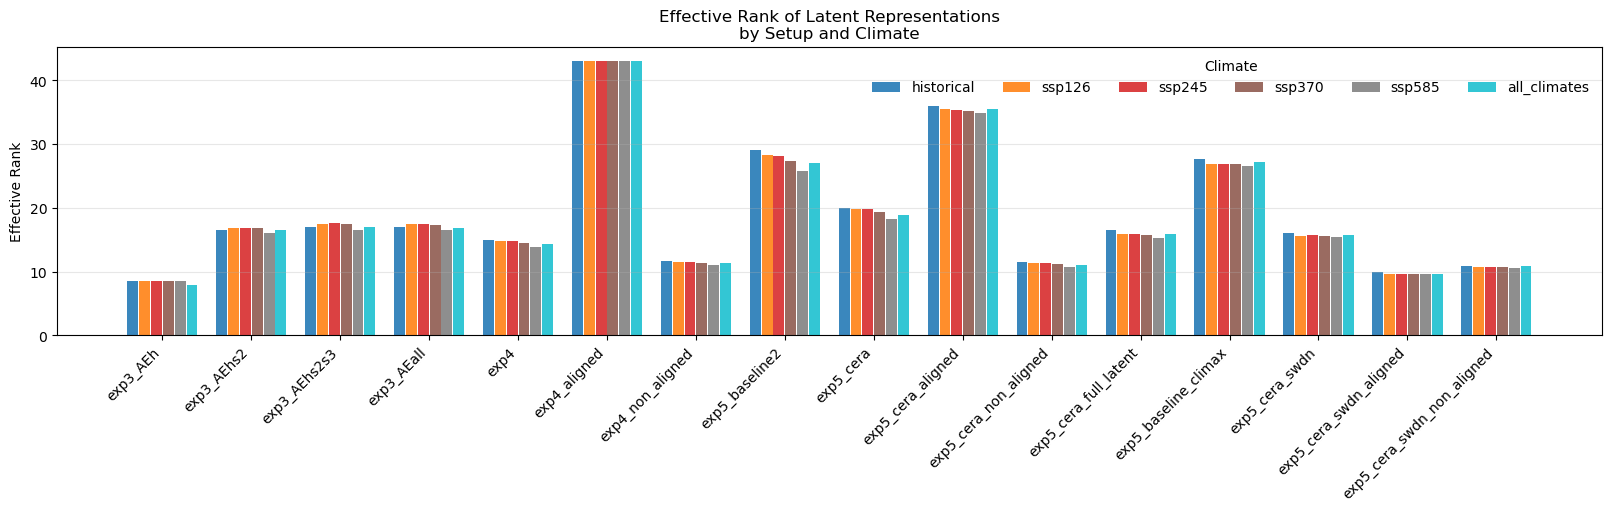

In [ ]:
# --- Table: (n_climates + 1) rows = climates + all_climates, 16 columns = setups ---
# We transpose erank_df so rows = climates and columns = setups, matching the requested shape.
erank_display = erank_df.T   # shape: (n_climates + 1) x 16

display(
    erank_display.style
    .format("{:.2f}")
    .background_gradient(axis=None, cmap="YlOrRd")
    .set_caption("Effective Rank by Climate (rows) and Setup (columns)")
    .set_table_styles([{"selector": "caption", "props": [("font-size", "14px"), ("font-weight", "bold")]}])
)

# --- Bar chart: one group of bars per setup, one bar per climate/all ---
fig, ax = plt.subplots(figsize=(16, 5), constrained_layout=True)

col_labels = list(erank_display.index)   # climates + "all_climates"
setup_labels = list(erank_display.columns)
n_cols = len(col_labels)
n_setups = len(setup_labels)
x = np.arange(n_setups)
width = 0.8 / n_cols

bar_colors = plt.cm.tab10(np.linspace(0, 0.9, n_cols))

for i, col in enumerate(col_labels):
    offset = (i - n_cols / 2 + 0.5) * width
    ax.bar(x + offset, erank_display.loc[col], width=width * 0.92,
           label=col, color=bar_colors[i], alpha=0.88)

ax.set_xticks(x)
ax.set_xticklabels(setup_labels, rotation=45, ha="right")
ax.set_ylabel("Effective Rank")
ax.set_title("Effective Rank of Latent Representations\nby Setup and Climate")
ax.legend(title="Climate", ncol=n_cols, loc="upper right", frameon=False)
ax.grid(axis="y", alpha=0.3)
plt.show()

setup,exp3_AEh,exp3_AEhs2,exp3_AEhs2s3,exp3_AEall,exp4,exp4_aligned,exp4_non_aligned,exp5_baseline2,exp5_cera,exp5_cera_aligned,exp5_cera_non_aligned,exp5_cera_full_latent,exp5_baseline_climax,exp5_cera_swdn,exp5_cera_swdn_aligned,exp5_cera_swdn_non_aligned
historical,0.133,0.257,0.265,0.265,0.235,0.895,0.725,0.456,0.313,0.750,0.715,0.258,0.431,0.252,0.206,0.684
ssp126,0.133,0.262,0.274,0.272,0.231,0.896,0.717,0.442,0.309,0.739,0.710,0.248,0.420,0.244,0.201,0.670
ssp245,0.133,0.264,0.275,0.274,0.232,0.897,0.721,0.440,0.309,0.737,0.713,0.249,0.421,0.246,0.202,0.675
ssp370,0.133,0.262,0.272,0.271,0.228,0.897,0.713,0.428,0.301,0.735,0.703,0.247,0.419,0.245,0.202,0.675
ssp585,0.133,0.252,0.258,0.258,0.218,0.896,0.689,0.404,0.286,0.726,0.676,0.240,0.416,0.240,0.200,0.665
all_climates,0.123,0.257,0.265,0.264,0.225,0.897,0.706,0.424,0.296,0.739,0.694,0.248,0.425,0.246,0.202,0.677


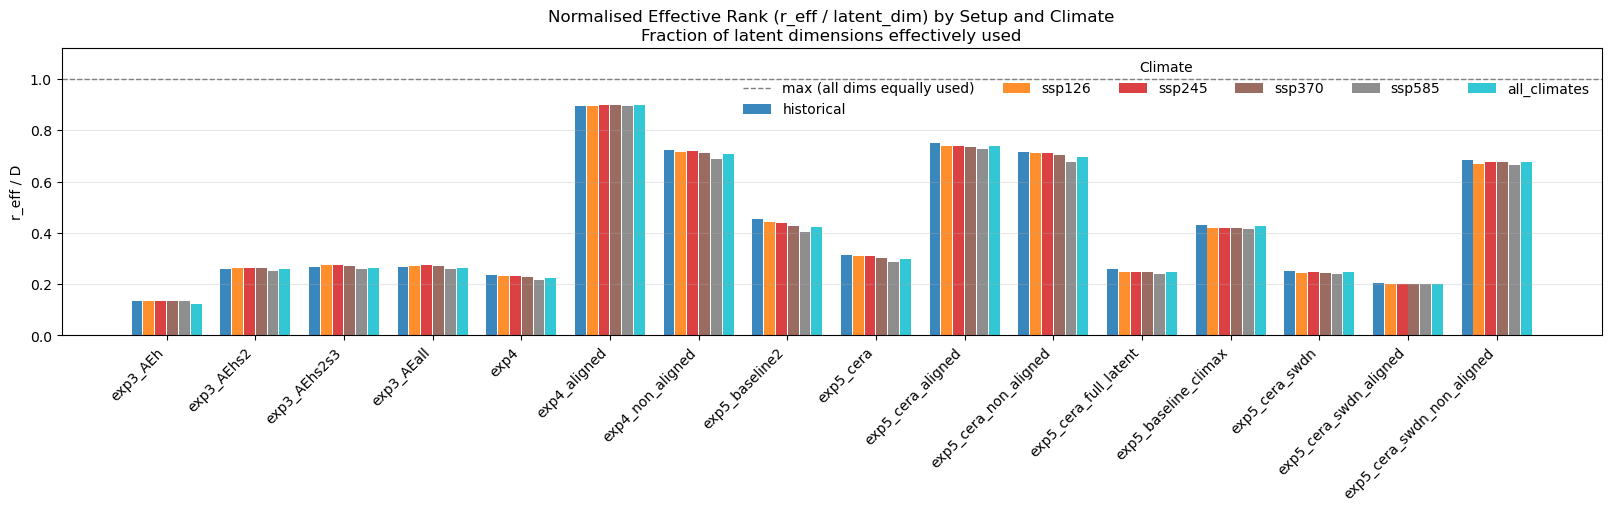

In [9]:
# --- Effective rank normalised by latent dimension (fraction of dimensions used) ---
# r_eff_norm = r_eff / D   where D = latent dimension of the setup (16, 48 or 64)
# Values in (0, 1]: 1.0 means all dimensions are equally used (flat spectrum),
# values close to 0 mean variance is concentrated on very few directions.

# Build a Series: setup_name -> latent_dim
latent_dims = pd.Series(
    {name: get_latent_for_setup(name, climate_order[0]).shape[1] for name in SETUPS},
    name="latent_dim",
)

# Normalise: divide every row of erank_df by the corresponding latent dimension
erank_norm_df = erank_df.div(latent_dims, axis=0)

# --- Table ---
erank_norm_display = erank_norm_df.T   # rows = climates + all_climates, columns = setups

display(
    erank_norm_display.style
    .format("{:.3f}")
    .background_gradient(axis=None, cmap="YlGn")
    .set_caption(
        "Effective Rank / Latent Dimension  (fraction of dimensions used) — "
        "by Climate (rows) and Setup (columns)"
    )
    .set_table_styles([{"selector": "caption", "props": [("font-size", "14px"), ("font-weight", "bold")]}])
)

# --- Bar chart (same layout as the absolute effective rank chart above) ---
fig, ax = plt.subplots(figsize=(16, 5), constrained_layout=True)

col_labels_n  = list(erank_norm_display.index)
setup_labels_n = list(erank_norm_display.columns)
n_cols_n   = len(col_labels_n)
n_setups_n = len(setup_labels_n)
x_n   = np.arange(n_setups_n)
w_n   = 0.8 / n_cols_n
bar_colors_n = plt.cm.tab10(np.linspace(0, 0.9, n_cols_n))

for i, col in enumerate(col_labels_n):
    offset = (i - n_cols_n / 2 + 0.5) * w_n
    ax.bar(x_n + offset, erank_norm_display.loc[col], width=w_n * 0.92,
           label=col, color=bar_colors_n[i], alpha=0.88)

ax.axhline(1.0, color="gray", linestyle="--", linewidth=1.0, label="max (all dims equally used)")
ax.set_xticks(x_n)
ax.set_xticklabels(setup_labels_n, rotation=45, ha="right")
ax.set_ylim(0, 1.12)
ax.set_ylabel("r_eff / D")
ax.set_title(
    "Normalised Effective Rank (r_eff / latent_dim) by Setup and Climate\n"
    "Fraction of latent dimensions effectively used"
)
ax.legend(title="Climate", ncol=n_cols_n, loc="upper right", frameon=False)
ax.grid(axis="y", alpha=0.3)
plt.show()

In [15]:
# --- Eigenvalue spectra of latent representations ---
# For each setup and each climate (+ all climates combined), compute the
# normalised eigenvalue spectrum:  p_i = lambda_i / sum(lambda)
# This shows how variance is distributed across the latent dimensions.

def compute_eigenvalue_spectrum(X: np.ndarray) -> np.ndarray:
    """Return normalised eigenvalues p_i = lambda_i / sum(lambda), decreasing order."""
    X = np.asarray(X, dtype=np.float64)
    n_components = min(X.shape[0] - 1, X.shape[1])
    pca = PCA(n_components=n_components, random_state=random_seed)
    pca.fit(X)
    ev = pca.explained_variance_
    ev = ev[ev > 0]
    return ev / ev.sum()

# Collect spectra for every setup × climate + all_climates
spectra = {}
for setup_name in SETUPS:
    spectra[setup_name] = {}
    all_chunks = []
    for climate in climate_order:
        X = get_latent_for_setup(setup_name, climate)
        spectra[setup_name][climate] = compute_eigenvalue_spectrum(X)
        all_chunks.append(X)
    spectra[setup_name]["all_climates"] = compute_eigenvalue_spectrum(np.vstack(all_chunks))

# --- Plot: one subplot per setup, one curve per climate + all_climates ---
all_labels  = list(climate_order) + ["all_climates"]
line_colors = [climate_colors.get(c, f"C{i}") for i, c in enumerate(climate_order)] + ["black"]
line_styles = ["-"] * len(climate_order) + ["--"]
line_widths = [1.3] * len(climate_order) + [2.0]

n_setups = len(SETUPS)
ncols = 4
nrows = (n_setups + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 5, nrows * 3.8), constrained_layout=True)
axes_flat = axes.flatten()

for idx, setup_name in enumerate(SETUPS):
    ax = axes_flat[idx]
    for label, color, ls, lw in zip(all_labels, line_colors, line_styles, line_widths):
        p = spectra[setup_name][label]
        ax.plot(range(1, len(p) + 1), p,
                color=color, linestyle=ls, linewidth=lw, alpha=0.85, label=label)
    ax.set_yscale("log")
    ax.set_title(setup_name, fontsize=9, fontweight="bold")
    ax.set_xlabel("Component index", fontsize=8)
    ax.set_ylabel("Variance fraction pᵢ  (log)", fontsize=8)
    ax.grid(which="both", alpha=0.25)
    ax.tick_params(labelsize=7)

for idx in range(n_setups, len(axes_flat)):
    axes_flat[idx].set_visible(False)

# Shared legend placed in the last (hidden) axes slot
legend_ax = axes_flat[n_setups] if n_setups < len(axes_flat) else axes_flat[-1]
legend_ax.set_visible(True)
legend_ax.axis("off")
handles, labels_leg = axes_flat[0].get_legend_handles_labels()
legend_ax.legend(handles, labels_leg, title="Climate", loc="center",
                 fontsize=10, title_fontsize=10, frameon=True)

fig.suptitle(
    "Eigenvalue Spectra of Latent Representations — one plot per setup\n"
    r"Normalised variance fraction  $p_i = \lambda_i \,/\, \sum_j \lambda_j$  (log scale)",
    fontsize=12, y=1.01
)
plt.show()

KeyboardInterrupt: 

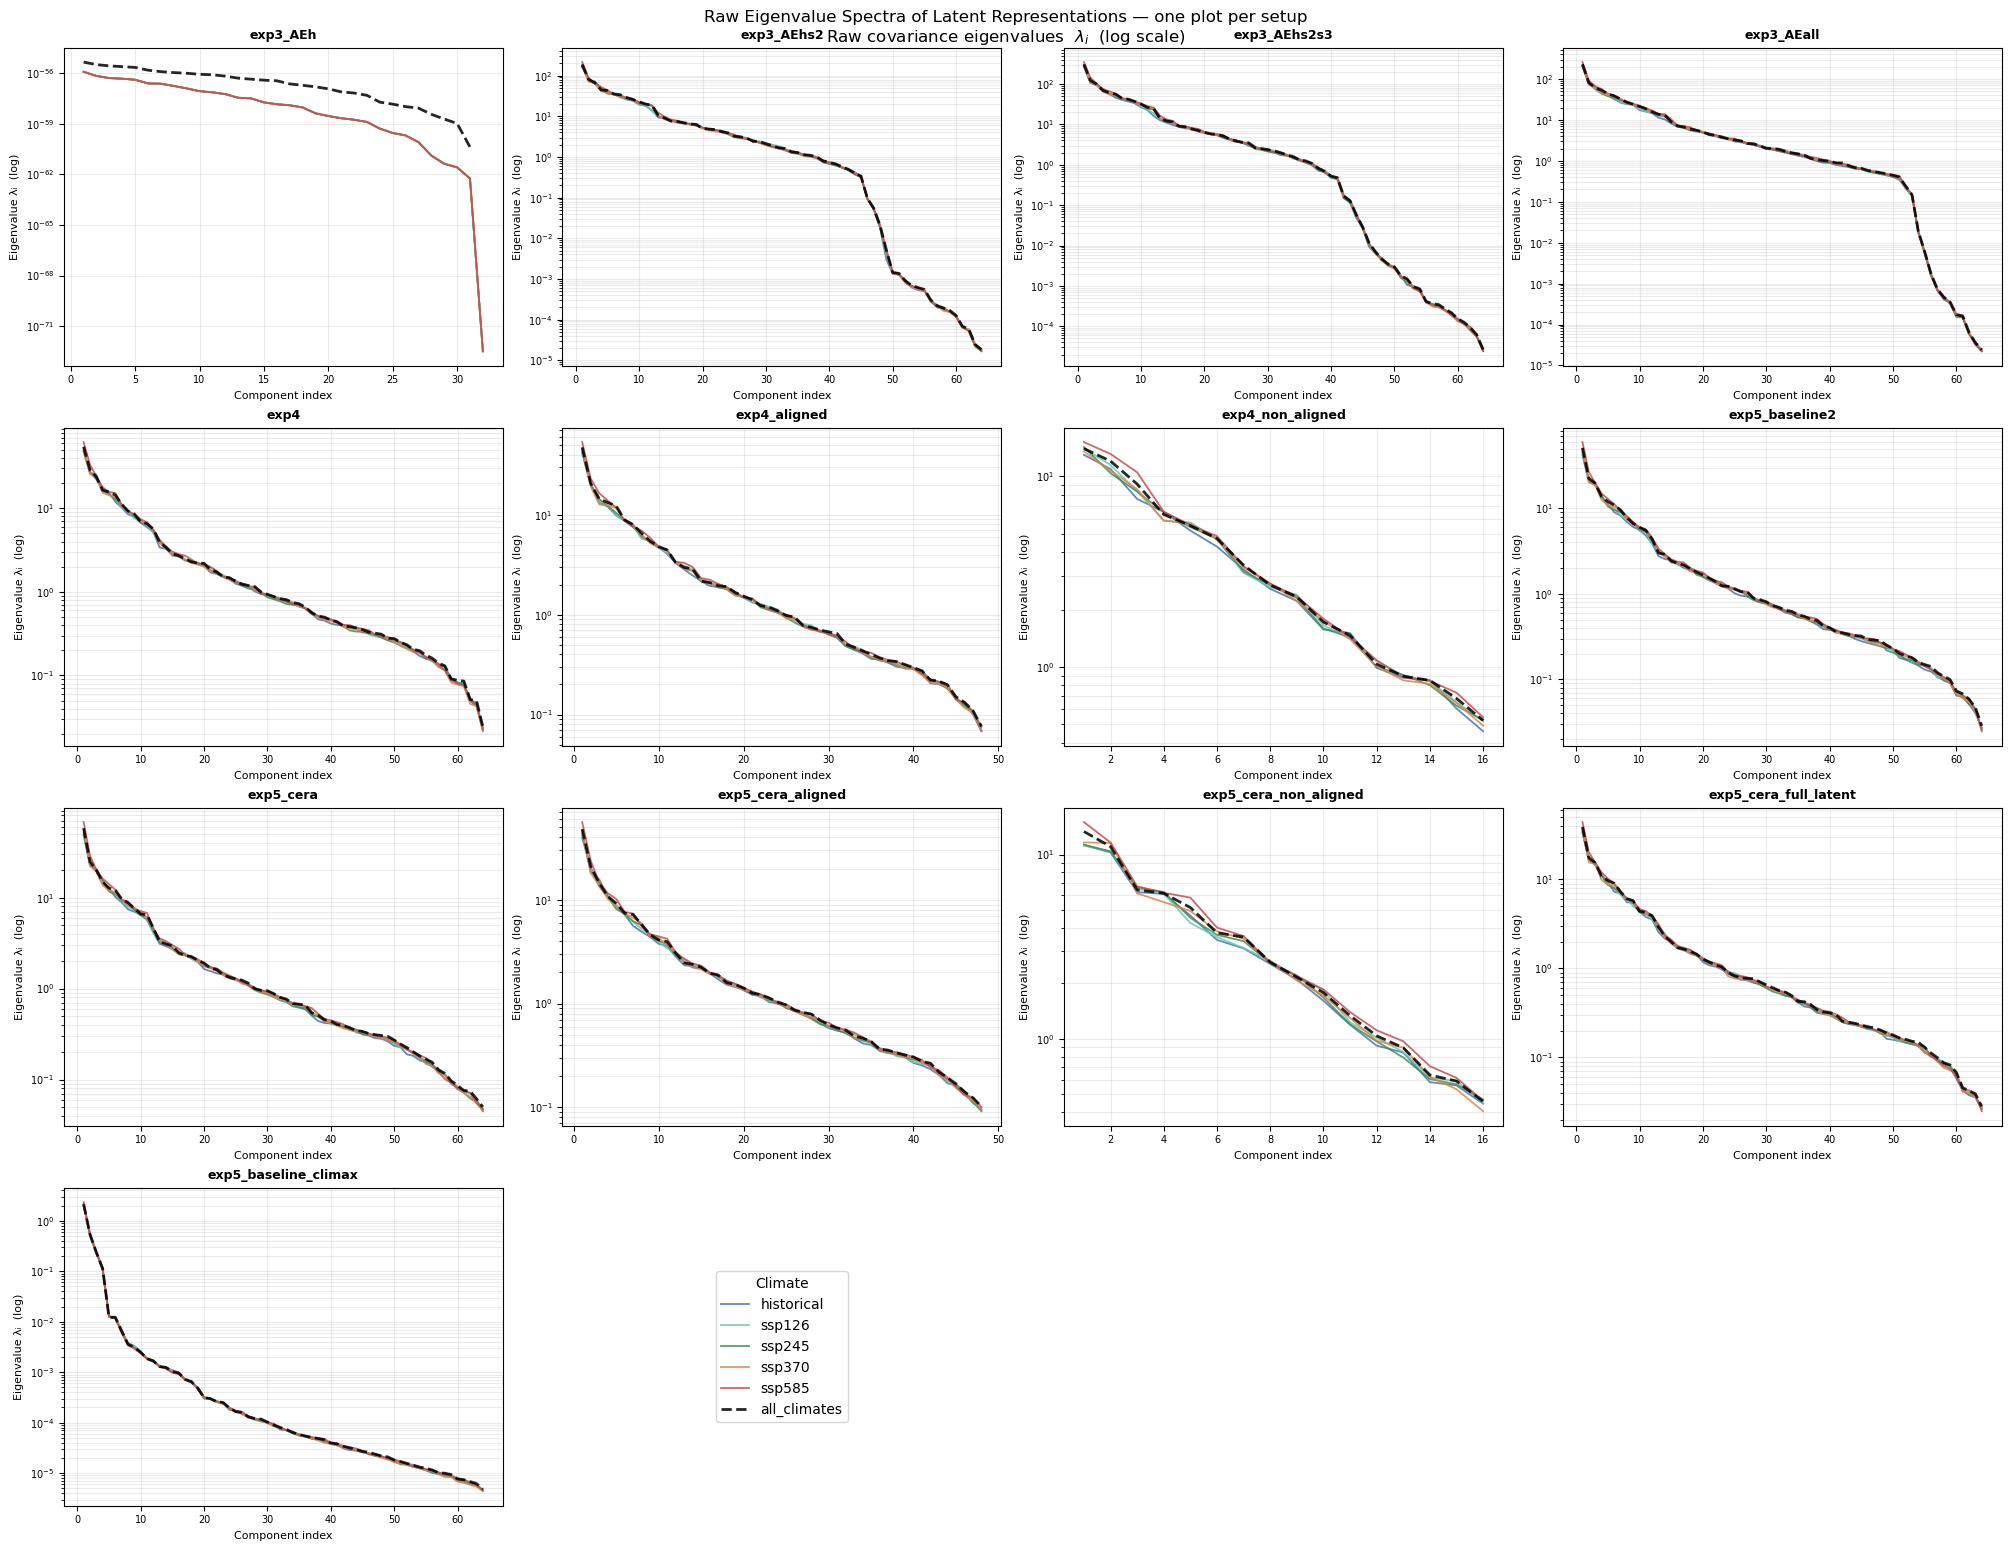

In [ ]:
# --- Raw eigenvalue spectra (λ_i, not normalised) ---
# Same layout as the normalised spectra above, but y-axis shows the raw
# eigenvalues λ_i of the covariance matrix (units = squared latent units).

def compute_raw_eigenspectrum(X: np.ndarray) -> np.ndarray:
    """Return raw eigenvalues λ_i in decreasing order (positive eigenvalues only)."""
    X = np.asarray(X, dtype=np.float64)
    n_components = min(X.shape[0] - 1, X.shape[1])
    pca = PCA(n_components=n_components, random_state=random_seed)
    pca.fit(X)
    ev = pca.explained_variance_
    return ev[ev > 0]

# Collect raw spectra for every setup × climate + all_climates
raw_spectra = {}
for setup_name in SETUPS:
    raw_spectra[setup_name] = {}
    all_chunks = []
    for climate in climate_order:
        X = get_latent_for_setup(setup_name, climate)
        raw_spectra[setup_name][climate] = compute_raw_eigenspectrum(X)
        all_chunks.append(X)
    raw_spectra[setup_name]["all_climates"] = compute_raw_eigenspectrum(np.vstack(all_chunks))

# --- Plot ---
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 5, nrows * 3.8), constrained_layout=True)
axes_flat = axes.flatten()

for idx, setup_name in enumerate(SETUPS):
    ax = axes_flat[idx]
    for label, color, ls, lw in zip(all_labels, line_colors, line_styles, line_widths):
        ev = raw_spectra[setup_name][label]
        ax.plot(range(1, len(ev) + 1), ev,
                color=color, linestyle=ls, linewidth=lw, alpha=0.85, label=label)
    ax.set_yscale("log")
    ax.set_title(setup_name, fontsize=9, fontweight="bold")
    ax.set_xlabel("Component index", fontsize=8)
    ax.set_ylabel("Eigenvalue λᵢ  (log)", fontsize=8)
    ax.grid(which="both", alpha=0.25)
    ax.tick_params(labelsize=7)

for idx in range(n_setups, len(axes_flat)):
    axes_flat[idx].set_visible(False)

legend_ax = axes_flat[n_setups] if n_setups < len(axes_flat) else axes_flat[-1]
legend_ax.set_visible(True)
legend_ax.axis("off")
handles, labels_leg = axes_flat[0].get_legend_handles_labels()
legend_ax.legend(handles, labels_leg, title="Climate", loc="center",
                 fontsize=10, title_fontsize=10, frameon=True)

fig.suptitle(
    "Raw Eigenvalue Spectra of Latent Representations — one plot per setup\n"
    r"Raw covariance eigenvalues  $\lambda_i$  (log scale)",
    fontsize=12, y=1.01
)
plt.show()

NameError: name 'spectra' is not defined

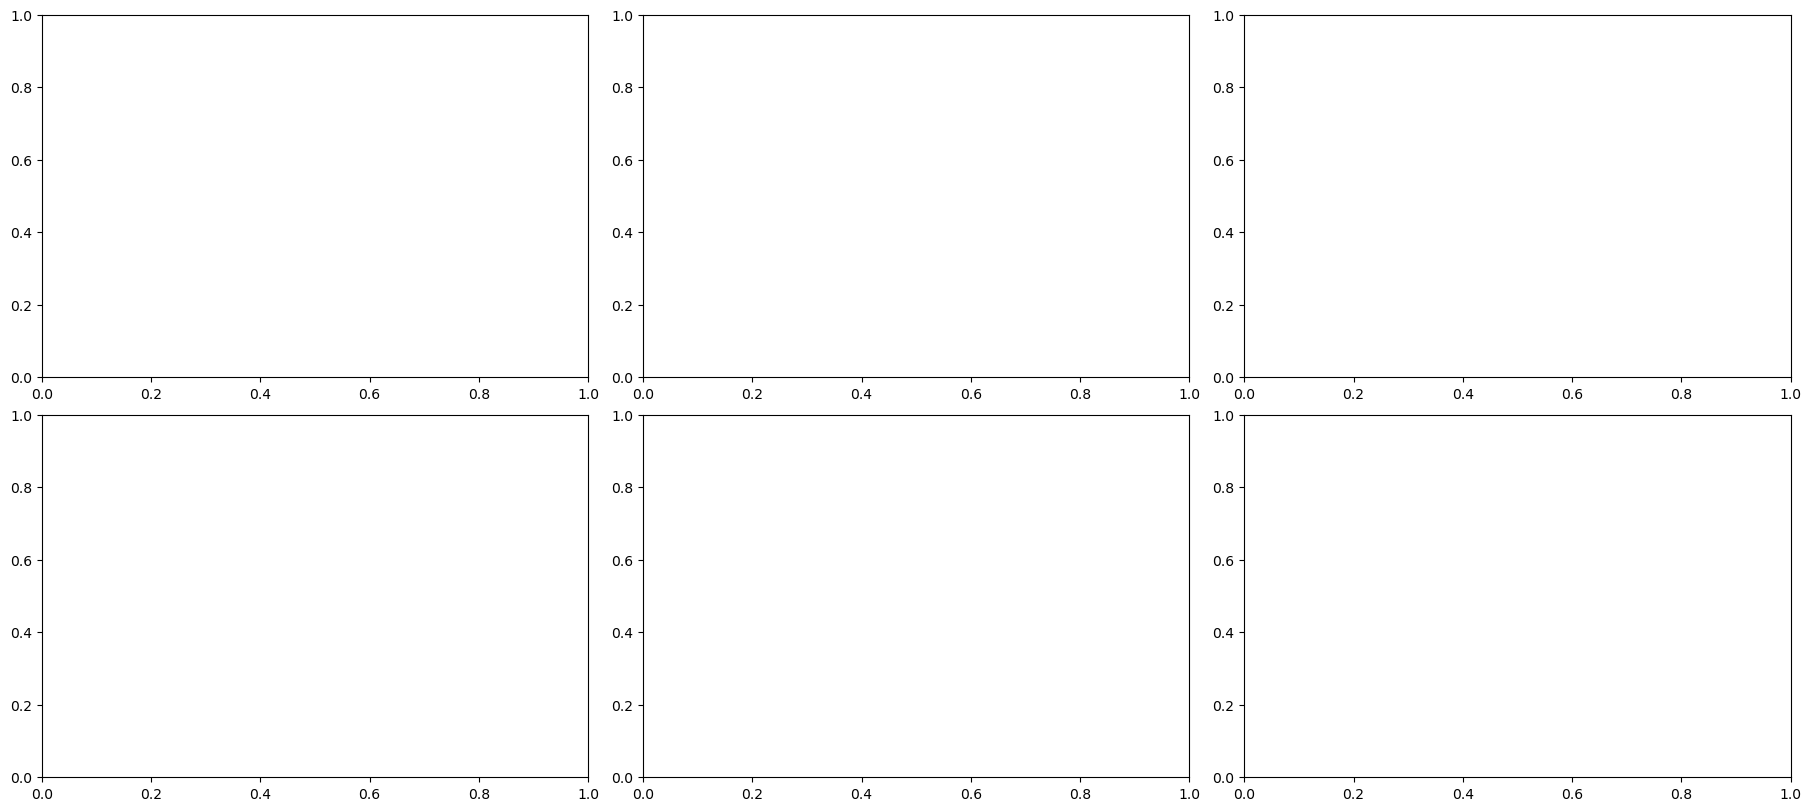

In [ ]:
# --- All setups on the same axes, one subplot per climate (+ all_climates) ---
# Each subplot shows the normalised eigenvalue spectrum p_i for all 16 setups.
# Setups with fewer dimensions (16, 48) simply have shorter curves — no padding.

climate_plot_labels = list(climate_order) + ["all_climates"]
n_climate_plots = len(climate_plot_labels)

# Colors and line styles for setups (16 setups → tab20 palette)
setup_colors = plt.cm.tab20(np.linspace(0, 1, len(SETUPS)))
# Visually group setups that share the same source with matching line styles
setup_ls_map = {
    "exp3_AEh":              "-",
    "exp3_AEhs2":            "-",
    "exp3_AEhs2s3":          "-",
    "exp3_AEall":            "-",
    "exp4":                  "-",
    "exp4_aligned":          "--",
    "exp4_non_aligned":      ":",
    "exp5_baseline2":        "-",
    "exp5_cera":             "-",
    "exp5_cera_aligned":     "--",
    "exp5_cera_non_aligned": ":",
    "exp5_cera_full_latent": "-",
    "exp5_baseline_climax":  "-",
    "exp5_cera_swdn":        "-",
    "exp5_cera_swdn_aligned":     "--",
    "exp5_cera_swdn_non_aligned": ":",
}

ncols_c = 3
nrows_c = (n_climate_plots + ncols_c - 1) // ncols_c

fig, axes = plt.subplots(nrows_c, ncols_c,
                         figsize=(ncols_c * 6, nrows_c * 4),
                         constrained_layout=True)
axes_flat = axes.flatten()

for plot_idx, clim_label in enumerate(climate_plot_labels):
    ax = axes_flat[plot_idx]
    for setup_idx, setup_name in enumerate(SETUPS):
        p = spectra[setup_name][clim_label]
        ax.plot(range(1, len(p) + 1), p,
                color=setup_colors[setup_idx],
                linestyle=setup_ls_map[setup_name],
                linewidth=1.6,
                alpha=0.85,
                label=setup_name)
    ax.set_yscale("log")
    title = clim_label if clim_label != "all_climates" else "all climates (combined)"
    ax.set_title(title, fontsize=10, fontweight="bold")
    ax.set_xlabel("Component index", fontsize=9)
    ax.set_ylabel("Variance fraction pᵢ  (log)", fontsize=9)
    ax.grid(which="both", alpha=0.25)
    ax.tick_params(labelsize=8)

# Hide leftover subplots
for idx in range(n_climate_plots, len(axes_flat)):
    axes_flat[idx].set_visible(False)

# Shared legend (placed in the first hidden slot, or appended outside)
if n_climate_plots < len(axes_flat):
    leg_ax = axes_flat[n_climate_plots]
    leg_ax.set_visible(True)
    leg_ax.axis("off")
    handles_s, labels_s = axes_flat[0].get_legend_handles_labels()
    leg_ax.legend(handles_s, labels_s, title="Setup",
                  loc="center", fontsize=9, title_fontsize=10, frameon=True)
else:
    handles_s, labels_s = axes_flat[0].get_legend_handles_labels()
    fig.legend(handles_s, labels_s, title="Setup",
               loc="lower center", ncol=4, fontsize=8,
               title_fontsize=9, frameon=True, bbox_to_anchor=(0.5, -0.05))

fig.suptitle(
    "Normalised Eigenvalue Spectra — all setups on the same axes, one plot per climate\n"
    r"$p_i = \lambda_i \,/\, \sum_j \lambda_j$  (log scale) — "
    "dashed/dotted = aligned/non-aligned sub-spaces",
    fontsize=11, y=1.02
)
plt.show()

## Part 2 - Study of the latent climate invariance

In [11]:
# --- Hyperparameters ---
CLASSIFIER_PCA_DIM = 16   # PCA projection dimension (same for all setups)
TRAIN_FRAC = 0.70
VAL_FRAC   = 0.15
TEST_FRAC  = 0.15         # remaining fraction

# --- Global index splits: defined once, applied identically to all setups ---
# All setups share the same test set (same samples, different latent views),
# so a single split per climate is meaningful and ensures strict comparability.
rng = np.random.default_rng(random_seed)
split_indices_by_climate = {}
_ref_source = "exp3_AEh"   # reference to determine N per climate
for climate in climate_order:
    N = latent_test_sets[_ref_source]["latent_test_by_climate"][climate].shape[0]
    idx = rng.permutation(N)
    n_test = int(TEST_FRAC * N)
    n_val  = int(VAL_FRAC  * N)
    split_indices_by_climate[climate] = {
        "train": idx[n_test + n_val :],
        "val":   idx[n_test : n_test + n_val],
        "test":  idx[:n_test],
    }

# Balanced sample count: same number of samples per climate per split
n_train_per_climate = min(len(split_indices_by_climate[c]["train"]) for c in climate_order)
n_val_per_climate   = min(len(split_indices_by_climate[c]["val"])   for c in climate_order)
n_test_per_climate  = min(len(split_indices_by_climate[c]["test"])  for c in climate_order)

climate_label = {c: i for i, c in enumerate(climate_order)}

print(f"Samples per climate — train: {n_train_per_climate}, val: {n_val_per_climate}, test: {n_test_per_climate}")
print(f"Total            — train: {n_train_per_climate * len(climate_order)}, "
      f"val: {n_val_per_climate * len(climate_order)}, "
      f"test: {n_test_per_climate * len(climate_order)}")
print(f"PCA target dim: {CLASSIFIER_PCA_DIM}")
print(f"Classifier: LogisticRegression (multinomial, lbfgs)")

Samples per climate — train: 262500, val: 56250, test: 56250
Total            — train: 1312500, val: 281250, test: 281250
PCA target dim: 16
Classifier: LogisticRegression (multinomial, lbfgs)


In [12]:
# --- For each setup: PCA (16D, fit on train only) -> LogisticRegression ---
# The PCA is re-fitted independently per setup. Setups that share the same
# source data (e.g. exp4 / exp4_aligned / exp4_non_aligned) receive different
# slices, so their PCA fits are independent and there is no data leakage.

classifier_results = {}

for setup_name in SETUPS:
    X_train_parts, X_val_parts, X_test_parts = [], [], []
    y_train_parts, y_val_parts, y_test_parts = [], [], []

    for climate in climate_order:
        X = get_latent_for_setup(setup_name, climate)  # already a copy
        ci = climate_label[climate]

        tr_idx = split_indices_by_climate[climate]["train"][:n_train_per_climate]
        va_idx = split_indices_by_climate[climate]["val"][:n_val_per_climate]
        te_idx = split_indices_by_climate[climate]["test"][:n_test_per_climate]

        X_train_parts.append(X[tr_idx])
        y_train_parts.append(np.full(n_train_per_climate, ci))
        X_val_parts.append(X[va_idx])
        y_val_parts.append(np.full(n_val_per_climate, ci))
        X_test_parts.append(X[te_idx])
        y_test_parts.append(np.full(n_test_per_climate, ci))

    X_train_raw = np.vstack(X_train_parts)
    y_train     = np.concatenate(y_train_parts)
    X_val_raw   = np.vstack(X_val_parts)
    y_val       = np.concatenate(y_val_parts)
    X_test_raw  = np.vstack(X_test_parts)
    y_test      = np.concatenate(y_test_parts)

    # PCA fitted on train data only (avoids leakage from val/test)
    n_pca = min(CLASSIFIER_PCA_DIM, X_train_raw.shape[1], X_train_raw.shape[0] - 1)
    pca_clf = PCA(n_components=n_pca, random_state=random_seed)
    X_train = pca_clf.fit_transform(X_train_raw)
    X_val   = pca_clf.transform(X_val_raw)
    X_test  = pca_clf.transform(X_test_raw)

    # Logistic regression (same architecture for all setups)
    clf = LogisticRegression(
        multi_class="multinomial",
        solver="lbfgs",
        max_iter=2000,
        random_state=random_seed,
    )
    clf.fit(X_train, y_train)

    val_acc  = float(clf.score(X_val,  y_val))
    test_acc = float(clf.score(X_test, y_test))
    conf_mat = confusion_matrix(y_test, clf.predict(X_test))

    classifier_results[setup_name] = {
        "val_accuracy":  val_acc,
        "test_accuracy": test_acc,
        "confusion_matrix": conf_mat,
        "n_pca_components": n_pca,
        "clf": clf,
    }
    print(f"  {setup_name:<28}  val={val_acc:.4f}  test={test_acc:.4f}")

random_baseline = 1.0 / len(climate_order)
print(f"\nRandom baseline: {random_baseline:.4f}")
print("Done.")

/glade/work/tsalin/conda-envs/cmip/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


  exp3_AEh                      val=0.2000  test=0.2000


/glade/work/tsalin/conda-envs/cmip/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


  exp3_AEhs2                    val=0.3826  test=0.3852


/glade/work/tsalin/conda-envs/cmip/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


...

  exp5_cera_swdn                val=0.3777  test=0.3796


/glade/work/tsalin/conda-envs/cmip/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


  exp5_cera_swdn_aligned        val=0.2145  test=0.2158


/glade/work/tsalin/conda-envs/cmip/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


  exp5_cera_swdn_non_aligned    val=0.3789  test=0.3810

Random baseline: 0.2000
Done.


,val accuracy,test accuracy
setup,,
exp3_AEh,0.2000,0.2000
exp3_AEhs2,0.3826,0.3852
exp3_AEhs2s3,0.3840,0.3859
exp3_AEall,0.3816,0.3832
exp4,0.3793,0.3810
exp4_aligned,0.2000,0.2000
exp4_non_aligned,0.3800,0.3819
exp5_baseline2,0.3774,0.3799
exp5_cera,0.3779,0.3813


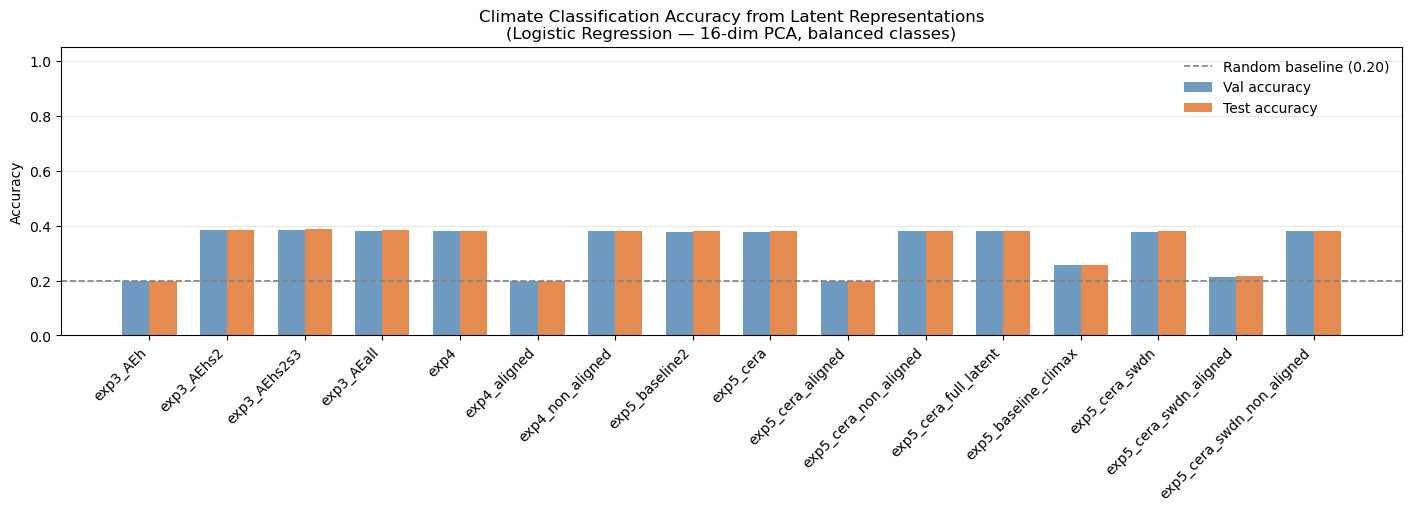

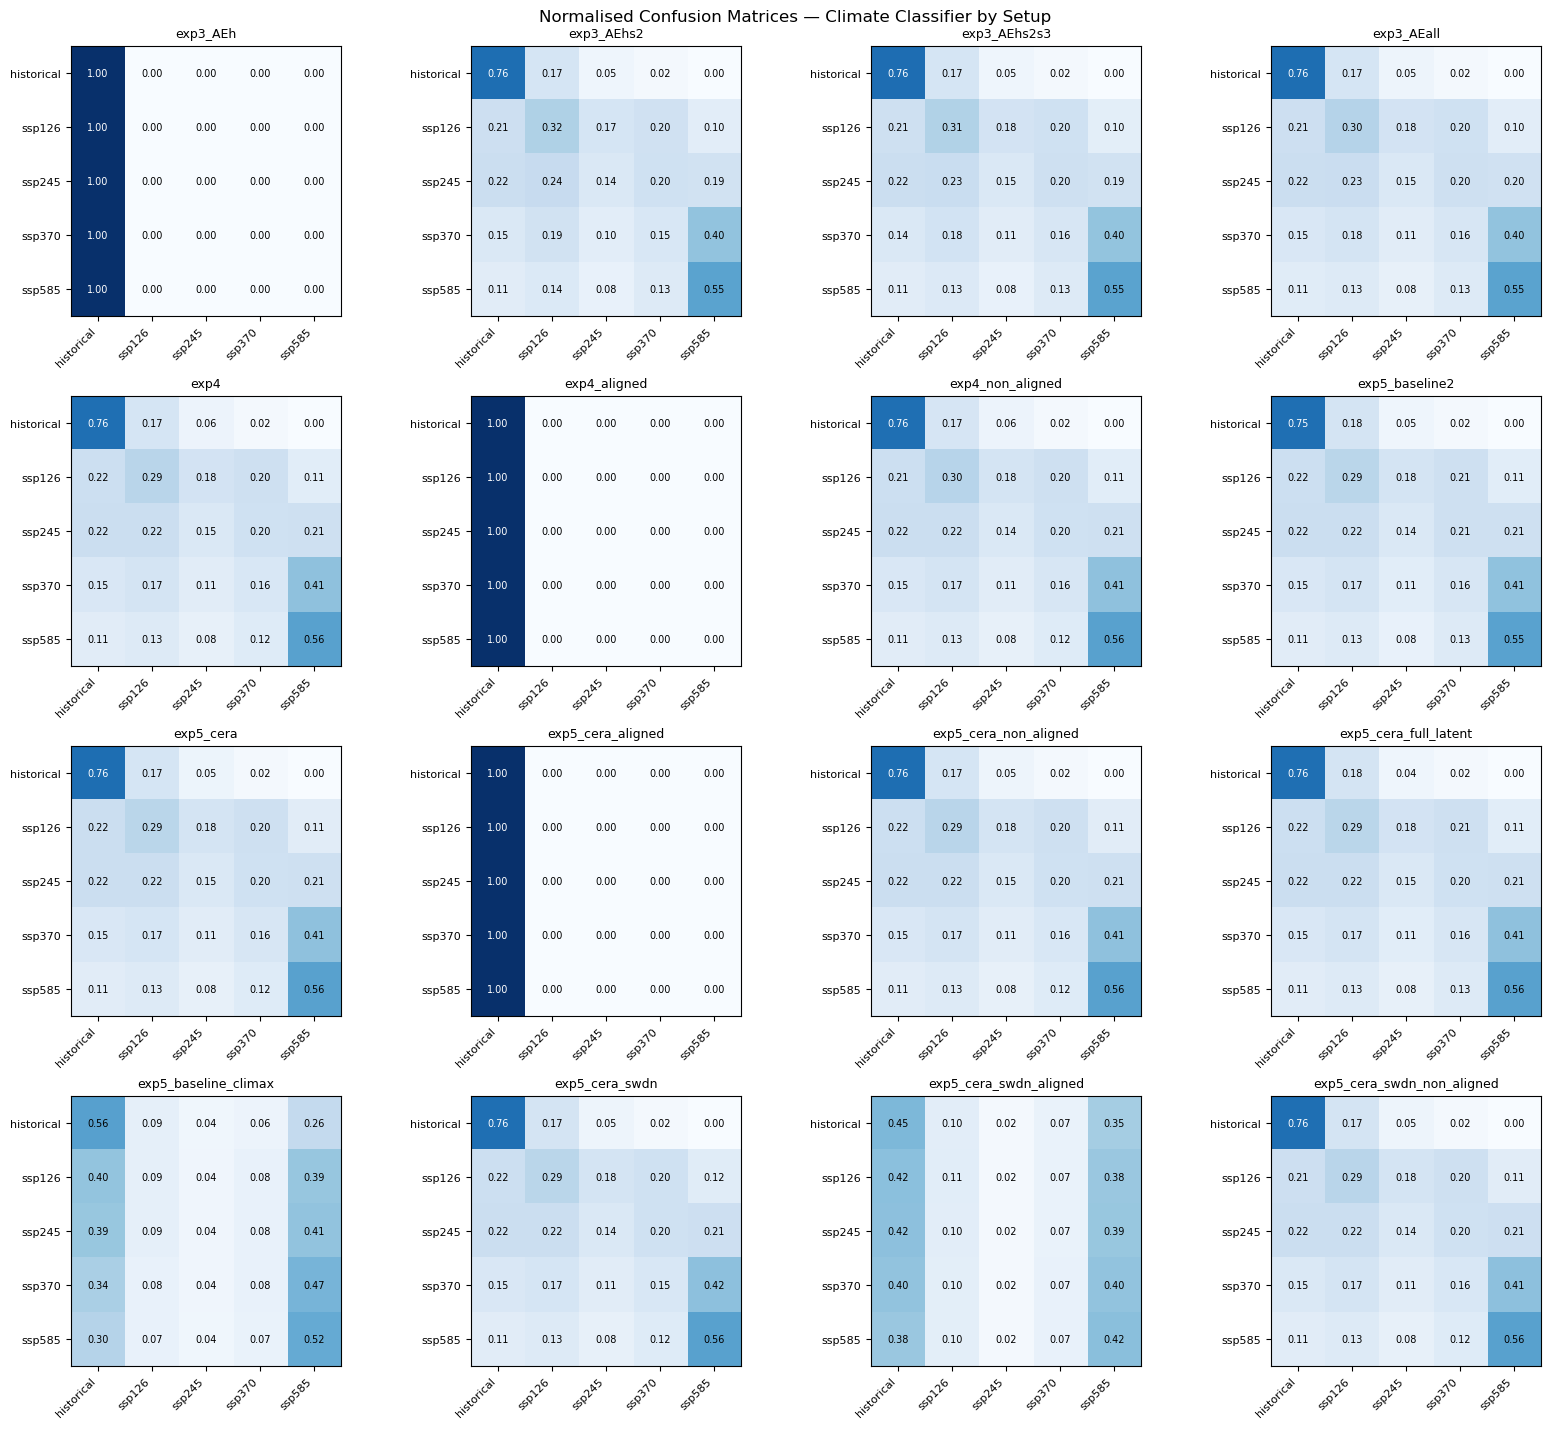

In [13]:
# --- Accuracy summary table ---
clf_rows = [
    {
        "setup": name,
        "val accuracy":  res["val_accuracy"],
        "test accuracy": res["test_accuracy"],
    }
    for name, res in classifier_results.items()
]
clf_df = pd.DataFrame(clf_rows).set_index("setup")

display(
    clf_df.style
    .format("{:.4f}")
    .background_gradient(axis=0, cmap="RdYlGn")
    .set_caption(
        f"Climate Classification Accuracy — LogReg on {CLASSIFIER_PCA_DIM}-dim PCA  "
        f"(random baseline = {random_baseline:.4f})"
    )
    .set_table_styles([{"selector": "caption", "props": [("font-size", "13px"), ("font-weight", "bold")]}])
)

# --- Bar chart: val and test accuracy per setup ---
fig, ax = plt.subplots(figsize=(14, 5), constrained_layout=True)
x = np.arange(len(clf_df))
width = 0.35
ax.bar(x - width / 2, clf_df["val accuracy"],  width, label="Val accuracy",  color="#5B8DB8", alpha=0.88)
ax.bar(x + width / 2, clf_df["test accuracy"], width, label="Test accuracy", color="#E07B39", alpha=0.88)
ax.axhline(random_baseline, color="gray", linestyle="--", linewidth=1.2,
           label=f"Random baseline ({random_baseline:.2f})")
ax.set_xticks(x)
ax.set_xticklabels(clf_df.index, rotation=45, ha="right")
ax.set_ylim(0.0, 1.05)
ax.set_ylabel("Accuracy")
ax.set_title(
    f"Climate Classification Accuracy from Latent Representations\n"
    f"(Logistic Regression — {CLASSIFIER_PCA_DIM}-dim PCA, balanced classes)"
)
ax.legend(frameon=False)
ax.grid(axis="y", alpha=0.3)
plt.show()

# --- Confusion matrices for each setup ---
n_setups = len(classifier_results)
ncols = 4
nrows = (n_setups + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 3.5), constrained_layout=True)
axes_flat = axes.flatten()

for idx, (setup_name, res) in enumerate(classifier_results.items()):
    ax = axes_flat[idx]
    cm = res["confusion_matrix"]
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    im = ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
    ax.set_xticks(range(len(climate_order)))
    ax.set_yticks(range(len(climate_order)))
    ax.set_xticklabels(climate_order, rotation=45, ha="right", fontsize=8)
    ax.set_yticklabels(climate_order, fontsize=8)
    ax.set_title(setup_name, fontsize=9)
    for i in range(len(climate_order)):
        for j in range(len(climate_order)):
            ax.text(j, i, f"{cm_norm[i, j]:.2f}", ha="center", va="center",
                    fontsize=7, color="white" if cm_norm[i, j] > 0.6 else "black")

# Hide unused axes
for idx in range(n_setups, len(axes_flat)):
    axes_flat[idx].set_visible(False)

fig.suptitle("Normalised Confusion Matrices — Climate Classifier by Setup", fontsize=12, y=1.01)
plt.show()

### MLP Classifier — upper bound on linearly and non-linearly accessible climate information

Same experimental protocol as the logistic regression above:
- identical train / val / test splits (same indices, same balanced sample counts per climate)
- identical PCA projection to 16 dimensions (re-fitted on train data only, same `random_seed` → deterministic, identical projections)
- one MLP per setup: 2 hidden layers × 64 neurons, ReLU activations, Adam optimiser with early stopping

The MLP can capture non-linear decision boundaries, so its accuracy provides an **upper bound** on the climate information present in the latent space regardless of its geometric organisation. Comparing MLP vs logistic regression accuracy reveals whether climate information is linearly accessible or hidden in non-linear structure.

In [ ]:
from sklearn.neural_network import MLPClassifier

# --- For each setup: same PCA (16D) -> MLP (2 x 64, ReLU, Adam) ---
# The PCA is re-fitted with the same seed and data as in the logistic regression
# cell, producing bitwise-identical 16D projections.

mlp_results = {}

for setup_name in SETUPS:
    X_train_parts, X_val_parts, X_test_parts = [], [], []
    y_train_parts, y_val_parts, y_test_parts = [], [], []

    for climate in climate_order:
        X  = get_latent_for_setup(setup_name, climate)
        ci = climate_label[climate]

        tr_idx = split_indices_by_climate[climate]["train"][:n_train_per_climate]
        va_idx = split_indices_by_climate[climate]["val"][:n_val_per_climate]
        te_idx = split_indices_by_climate[climate]["test"][:n_test_per_climate]

        X_train_parts.append(X[tr_idx])
        y_train_parts.append(np.full(n_train_per_climate, ci))
        X_val_parts.append(X[va_idx])
        y_val_parts.append(np.full(n_val_per_climate, ci))
        X_test_parts.append(X[te_idx])
        y_test_parts.append(np.full(n_test_per_climate, ci))

    X_train_raw = np.vstack(X_train_parts)
    y_train     = np.concatenate(y_train_parts)
    X_val_raw   = np.vstack(X_val_parts)
    y_val       = np.concatenate(y_val_parts)
    X_test_raw  = np.vstack(X_test_parts)
    y_test      = np.concatenate(y_test_parts)

    # Identical PCA to logistic regression (same seed + data = identical projection)
    n_pca   = min(CLASSIFIER_PCA_DIM, X_train_raw.shape[1], X_train_raw.shape[0] - 1)
    pca_mlp = PCA(n_components=n_pca, random_state=random_seed)
    X_train = pca_mlp.fit_transform(X_train_raw)
    X_val   = pca_mlp.transform(X_val_raw)
    X_test  = pca_mlp.transform(X_test_raw)

    # MLP: 2 hidden layers × 64 neurons, ReLU, Adam
    # early_stopping uses 10 % of the training data internally for early stopping
    mlp = MLPClassifier(
        hidden_layer_sizes=(64, 64),
        activation="relu",
        solver="adam",
        max_iter=500,
        random_state=random_seed,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=20,
        verbose=False,
    )
    mlp.fit(X_train, y_train)

    val_acc  = float(mlp.score(X_val,  y_val))
    test_acc = float(mlp.score(X_test, y_test))
    conf_mat = confusion_matrix(y_test, mlp.predict(X_test))

    mlp_results[setup_name] = {
        "val_accuracy":     val_acc,
        "test_accuracy":    test_acc,
        "confusion_matrix": conf_mat,
        "n_pca_components": n_pca, 
        "n_iter":           mlp.n_iter_,
        "mlp":              mlp,
    }
    print(f"  {setup_name:<28}  val={val_acc:.4f}  test={test_acc:.4f}  (epochs={mlp.n_iter_})")

print(f"\nRandom baseline: {random_baseline:.4f}")
print("Done.")

  exp3_AEh                      val=0.2000  test=0.2000  (epochs=23)
  exp3_AEhs2                    val=0.4469  test=0.4472  (epochs=34)
  exp3_AEhs2s3                  val=0.4485  test=0.4496  (epochs=66)
  exp3_AEall                    val=0.4500  test=0.4499  (epochs=56)
  exp4                          val=0.4491  test=0.4493  (epochs=55)
  exp4_aligned                  val=0.2255  test=0.2260  (epochs=86)
  exp4_non_aligned              val=0.4496  test=0.4508  (epochs=97)
  exp5_baseline2                val=0.4482  test=0.4501  (epochs=46)
  exp5_cera                     val=0.4522  test=0.4524  (epochs=104)
  exp5_cera_aligned             val=0.2639  test=0.2641  (epochs=119)


/glade/work/tsalin/conda-envs/cmip/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:788: UserWarning: Training interrupted by user.
  warnings.warn("Training interrupted by user.")


  exp5_cera_non_aligned         val=0.4483  test=0.4481  (epochs=31)


/glade/work/tsalin/conda-envs/cmip/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:788: UserWarning: Training interrupted by user.
  warnings.warn("Training interrupted by user.")


  exp5_cera_full_latent         val=0.4400  test=0.4422  (epochs=7)


,val accuracy,test accuracy
setup,,
exp3_AEh,0.2000,0.2000
exp3_AEhs2,0.4491,0.4481
exp3_AEhs2s3,0.4493,0.4481
exp3_AEall,0.4461,0.4451
exp4,0.4515,0.4511
exp4_aligned,0.3202,0.3218
exp4_non_aligned,0.4323,0.4321
exp5_baseline2,0.4538,0.4519
exp5_cera,0.4529,0.4519


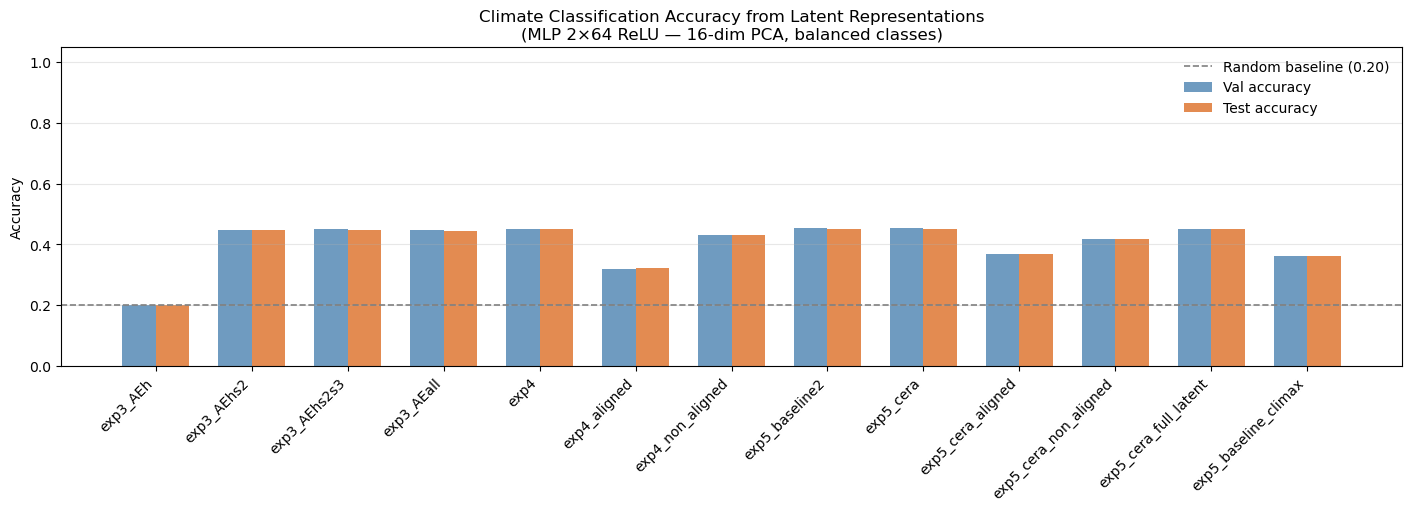

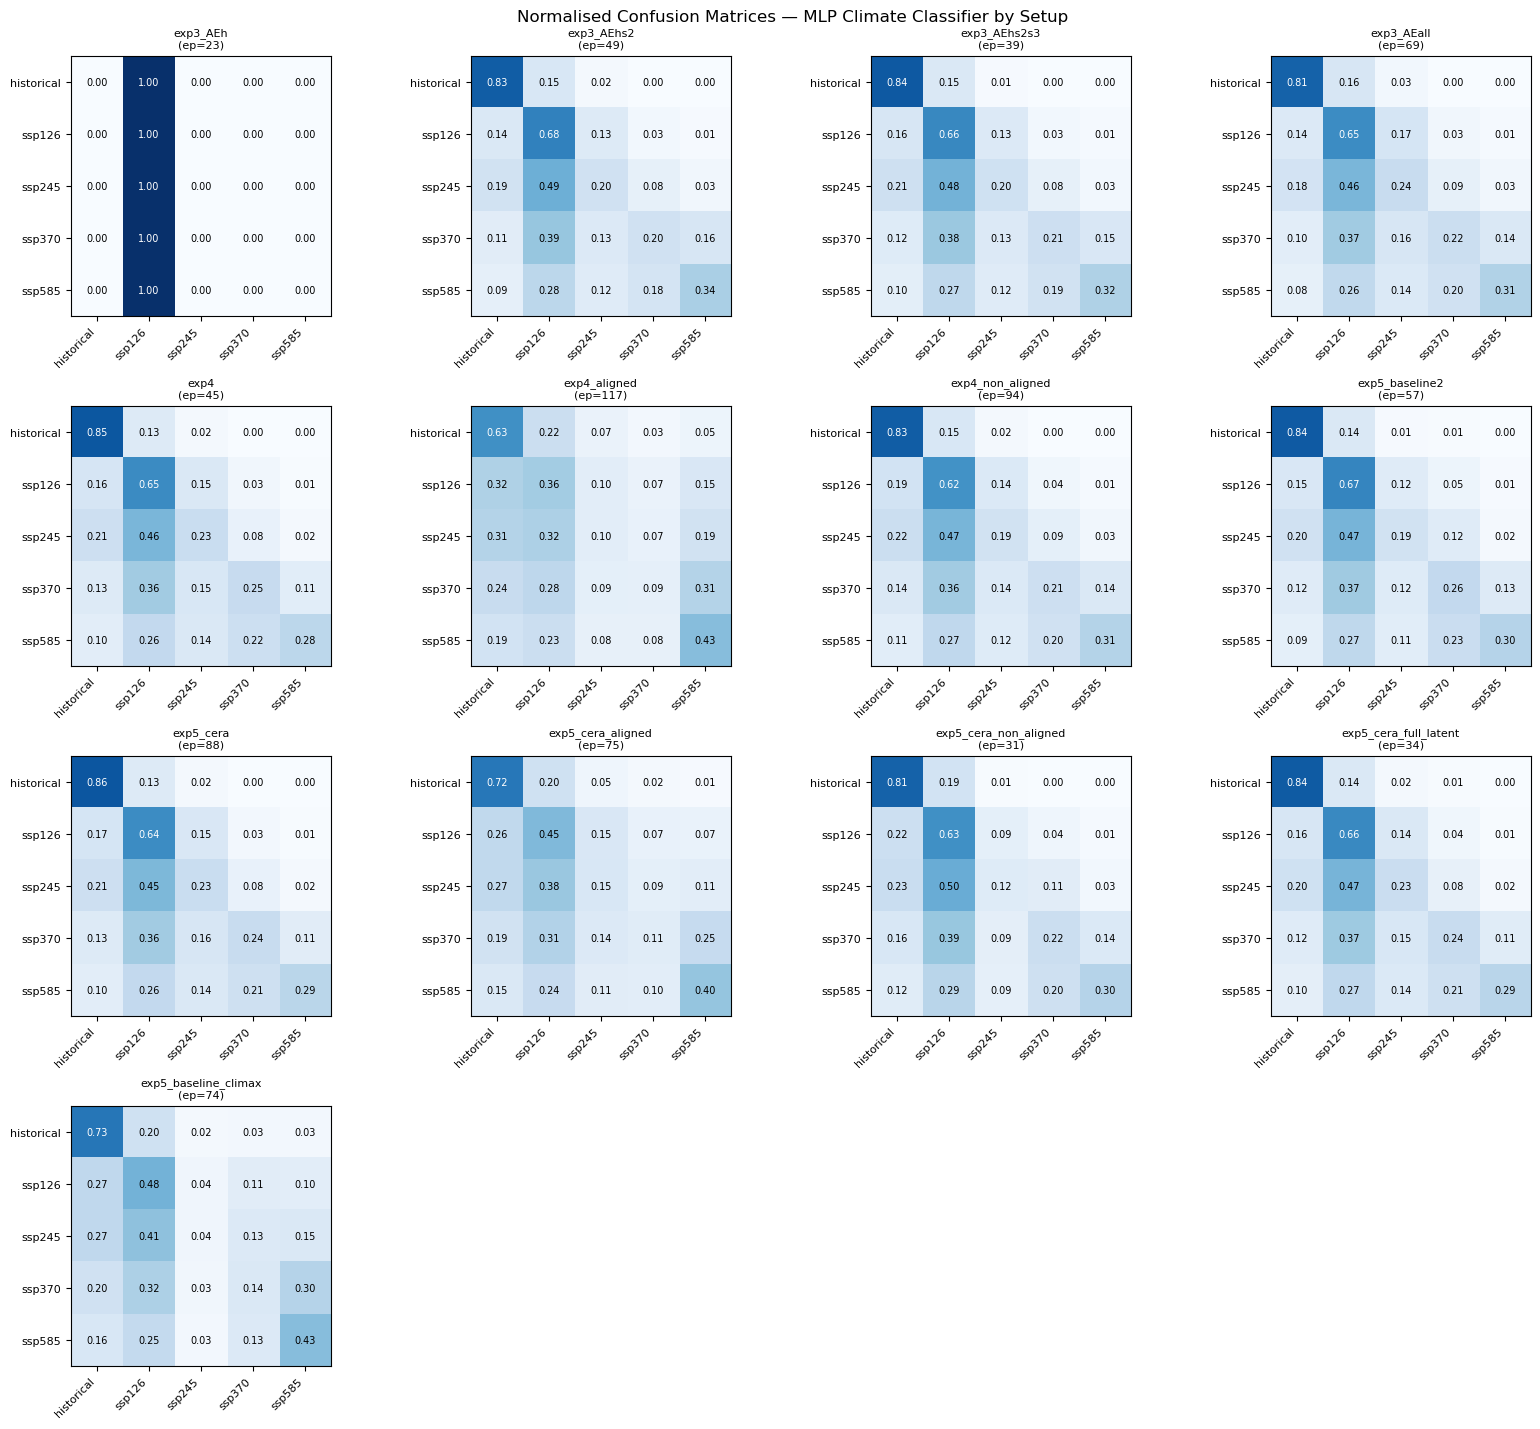

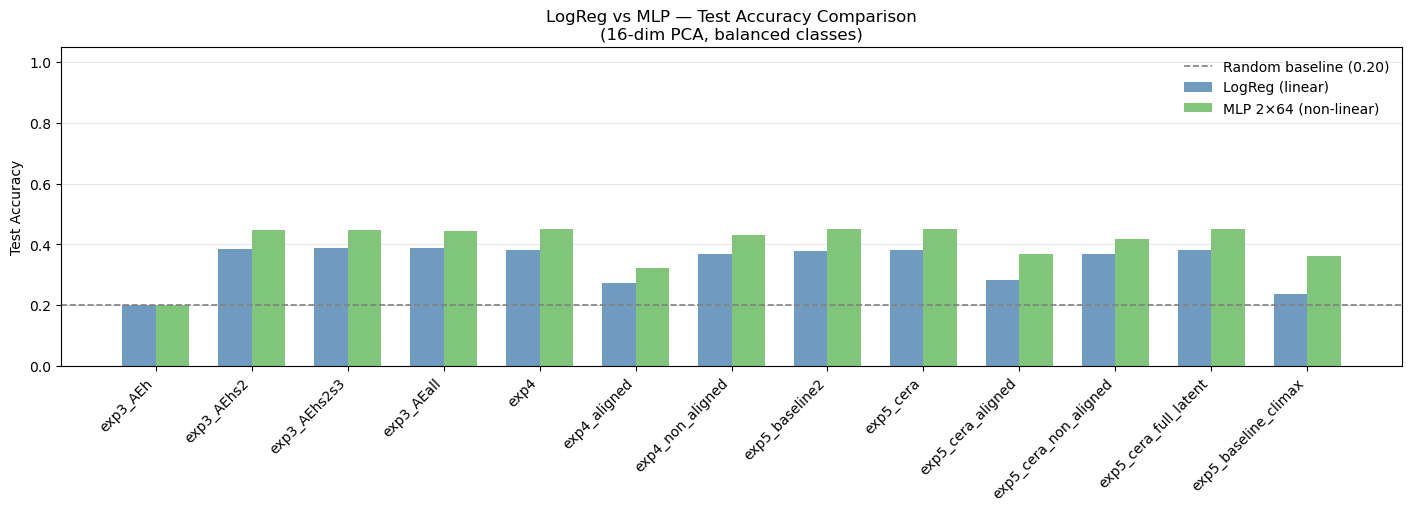

In [24]:
# --- Accuracy summary table ---
mlp_rows = [
    {
        "setup":         name,
        "val accuracy":  res["val_accuracy"],
        "test accuracy": res["test_accuracy"],
    }
    for name, res in mlp_results.items()
]
mlp_df = pd.DataFrame(mlp_rows).set_index("setup")

display(
    mlp_df.style
    .format("{:.4f}")
    .background_gradient(axis=0, cmap="RdYlGn")
    .set_caption(
        f"Climate Classification Accuracy — MLP (2×64, ReLU) on {CLASSIFIER_PCA_DIM}-dim PCA  "
        f"(random baseline = {random_baseline:.4f})"
    )
    .set_table_styles([{"selector": "caption", "props": [("font-size", "13px"), ("font-weight", "bold")]}])
)

# --- Bar chart: val and test accuracy per setup ---
fig, ax = plt.subplots(figsize=(14, 5), constrained_layout=True)
x = np.arange(len(mlp_df))
width = 0.35
ax.bar(x - width / 2, mlp_df["val accuracy"],  width, label="Val accuracy",  color="#5B8DB8", alpha=0.88)
ax.bar(x + width / 2, mlp_df["test accuracy"], width, label="Test accuracy", color="#E07B39", alpha=0.88)
ax.axhline(random_baseline, color="gray", linestyle="--", linewidth=1.2,
           label=f"Random baseline ({random_baseline:.2f})")
ax.set_xticks(x)
ax.set_xticklabels(mlp_df.index, rotation=45, ha="right")
ax.set_ylim(0.0, 1.05)
ax.set_ylabel("Accuracy")
ax.set_title(
    f"Climate Classification Accuracy from Latent Representations\n"
    f"(MLP 2×64 ReLU — {CLASSIFIER_PCA_DIM}-dim PCA, balanced classes)"
)
ax.legend(frameon=False)
ax.grid(axis="y", alpha=0.3)
plt.show()

# --- Confusion matrices for each setup ---
n_setups = len(mlp_results)
ncols = 4
nrows = (n_setups + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 3.5), constrained_layout=True)
axes_flat = axes.flatten()

for idx, (setup_name, res) in enumerate(mlp_results.items()):
    ax = axes_flat[idx]
    cm = res["confusion_matrix"]
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
    ax.set_xticks(range(len(climate_order)))
    ax.set_yticks(range(len(climate_order)))
    ax.set_xticklabels(climate_order, rotation=45, ha="right", fontsize=8)
    ax.set_yticklabels(climate_order, fontsize=8)
    ax.set_title(f"{setup_name}\n(ep={res['n_iter']})", fontsize=8)
    for i in range(len(climate_order)):
        for j in range(len(climate_order)):
            ax.text(j, i, f"{cm_norm[i, j]:.2f}", ha="center", va="center",
                    fontsize=7, color="white" if cm_norm[i, j] > 0.6 else "black")

for idx in range(n_setups, len(axes_flat)):
    axes_flat[idx].set_visible(False)

fig.suptitle("Normalised Confusion Matrices — MLP Climate Classifier by Setup", fontsize=12, y=1.01)
plt.show()

# --- Side-by-side comparison: LogReg vs MLP (test accuracy) ---
fig, ax = plt.subplots(figsize=(14, 5), constrained_layout=True)
x = np.arange(len(mlp_df))
width = 0.35
logreg_test = [classifier_results[s]["test_accuracy"] for s in mlp_results]
mlp_test    = [mlp_results[s]["test_accuracy"]        for s in mlp_results]

ax.bar(x - width / 2, logreg_test, width, label="LogReg (linear)", color="#5B8DB8", alpha=0.88)
ax.bar(x + width / 2, mlp_test,    width, label="MLP 2×64 (non-linear)", color="#6DBF67", alpha=0.88)
ax.axhline(random_baseline, color="gray", linestyle="--", linewidth=1.2,
           label=f"Random baseline ({random_baseline:.2f})")
ax.set_xticks(x)
ax.set_xticklabels(list(mlp_results.keys()), rotation=45, ha="right")
ax.set_ylim(0.0, 1.05)
ax.set_ylabel("Test Accuracy")
ax.set_title(
    f"LogReg vs MLP — Test Accuracy Comparison\n"
    f"({CLASSIFIER_PCA_DIM}-dim PCA, balanced classes)"
)
ax.legend(frameon=False)
ax.grid(axis="y", alpha=0.3)
plt.show()

## Part 3 - Study of the normalized distances between climates

### I. RMS dispersion

Note that RMS dispersion is not very informative as the different setups latent representations live indifferent geometrics spaces but it allows for a common normalisation of the latent spaces thus allowing a rigourous comparison of distances across setups.

setup,exp3_AEh,exp3_AEhs2,exp3_AEhs2s3,exp3_AEall,exp4,exp4_aligned,exp4_non_aligned,exp5_baseline2,exp5_cera,exp5_cera_aligned,exp5_cera_non_aligned,exp5_cera_full_latent,exp5_baseline_climax,exp5_cera_swdn,exp5_cera_swdn_aligned,exp5_cera_swdn_non_aligned
historical,0.0000,22.8433,22.2704,22.5234,0.1547,0.0343,0.1509,2.8682,0.1448,0.0620,0.1309,0.1985,2.7857,18.8627,9.1965,16.4689
ssp126,0.0000,22.9155,22.3146,22.6737,0.1563,0.0343,0.1525,2.8930,0.1455,0.0622,0.1315,0.2001,2.8404,19.0349,9.1962,16.6660
ssp245,0.0000,23.0798,22.5031,22.8619,0.1577,0.0344,0.1540,2.9165,0.1465,0.0623,0.1326,0.2015,2.8515,19.0942,9.1945,16.7347
ssp370,0.0000,23.5367,23.0470,23.4158,0.1615,0.0345,0.1577,2.9736,0.1496,0.0625,0.1359,0.2045,2.9040,19.2950,9.1638,16.9800
ssp585,0.0000,24.2392,23.8683,24.2485,0.1670,0.0346,0.1634,3.0587,0.1540,0.0628,0.1406,0.2094,2.9640,19.5933,9.1537,17.3235


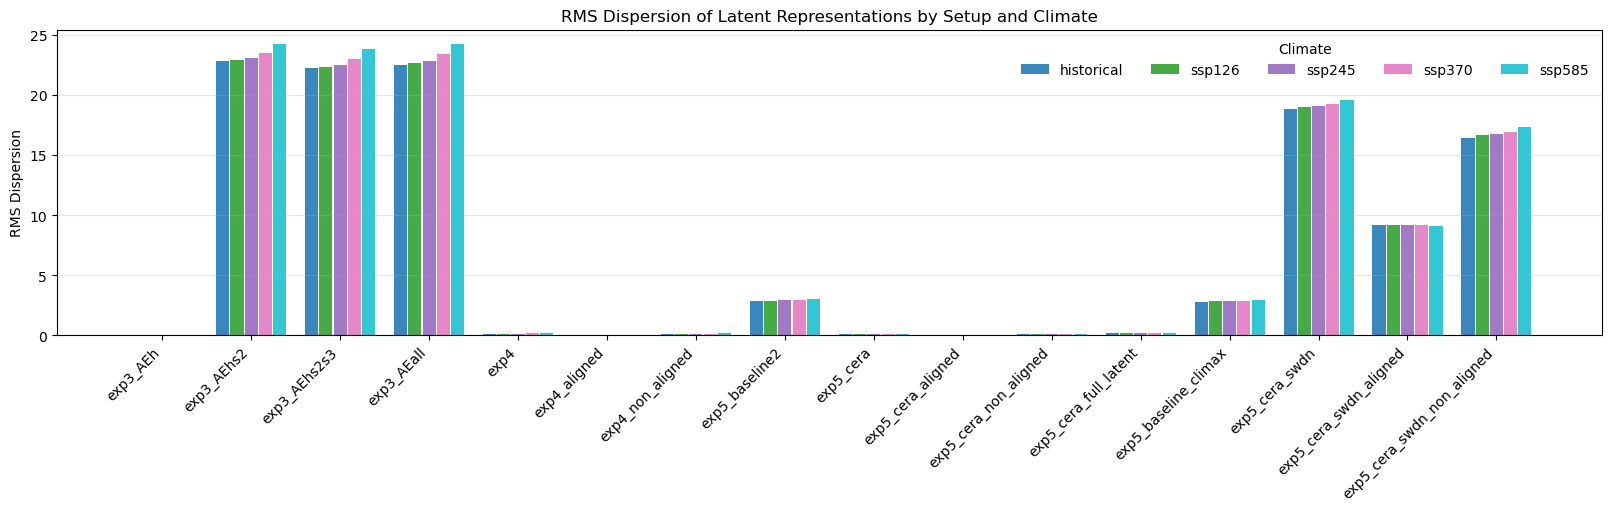

In [ ]:
# --- RMS dispersion for each setup × climate ---
# For a setup s and climate c with latent cloud X (N, D):
#   mu  = mean(X, axis=0)                        centroid
#   rms = sqrt( mean( ||x_i - mu||^2 ) )         scalar dispersion

rms_rows = []
for setup_name in SETUPS:
    row = {"setup": setup_name}
    for climate in climate_order:
        X = get_latent_for_setup(setup_name, climate)
        mu = X.mean(axis=0)
        rms = float(np.sqrt(np.mean(np.sum((X - mu) ** 2, axis=1))))
        row[climate] = rms
    rms_rows.append(row)

rms_df = pd.DataFrame(rms_rows).set_index("setup")

# --- Table: (n_climates) x 16  ---
rms_display = rms_df.T   # rows = climates, columns = setups

display(
    rms_display.style
    .format("{:.4f}")
    .background_gradient(axis=None, cmap="YlOrRd")
    .set_caption("RMS Dispersion of Latent Representations by Climate (rows) and Setup (columns)")
    .set_table_styles([{"selector": "caption", "props": [("font-size", "14px"), ("font-weight", "bold")]}])
)

# --- Bar chart ---
fig, ax = plt.subplots(figsize=(16, 5), constrained_layout=True)
setup_labels = list(rms_df.index)
n_setups = len(setup_labels)
n_climates = len(climate_order)
x = np.arange(n_setups)
width = 0.8 / n_climates
bar_colors = plt.cm.tab10(np.linspace(0, 0.9, n_climates))

for i, climate in enumerate(climate_order):
    offset = (i - n_climates / 2 + 0.5) * width
    ax.bar(x + offset, rms_df[climate], width=width * 0.92,
           label=climate, color=bar_colors[i], alpha=0.88)

ax.set_xticks(x)
ax.set_xticklabels(setup_labels, rotation=45, ha="right")
ax.set_ylabel("RMS Dispersion")
ax.set_title("RMS Dispersion of Latent Representations by Setup and Climate")
ax.legend(title="Climate", ncol=n_climates, loc="upper right", frameon=False)
ax.grid(axis="y", alpha=0.3)
plt.show()

### II. Distances between climates

In [ ]:
# ── Normalisation ──────────────────────────────────────────────────────────────
# For each setup we normalise ALL climates using the historical centroid and
# historical RMS dispersion (computed on raw latents, without PCA):
#
#   z' = (z - mu_hist) / s_hist
#
#   mu_hist  = mean over all historical samples (vector, shape D)
#   s_hist   = sqrt( mean ||z_i - mu_hist||^2 )   (scalar)
#
# This places the historical cloud at the origin with unit dispersion, and
# applies the exact same shift+scale to every SSP climate of the same setup.

def get_normalized_latents(setup_name):
    """Return a dict {climate: Z_norm} after historical-based normalisation."""
    X_hist = get_latent_for_setup(setup_name, "historical")
    mu_hist = X_hist.mean(axis=0)                                   # (D,)
    s_hist  = float(np.sqrt(np.mean(np.sum((X_hist - mu_hist) ** 2, axis=1))))
    if s_hist <= 0:
        raise ValueError(f"s_hist is zero for setup {setup_name}.")
    return {
        climate: (get_latent_for_setup(setup_name, climate) - mu_hist) / s_hist
        for climate in climate_order
    }, mu_hist, s_hist


def subsample(X, frac=0.1, seed=42):
    """Return a random subset containing `frac` of the rows of X."""
    rng = np.random.default_rng(seed)
    n = max(1, int(len(X) * frac))
    idx = rng.choice(len(X), n, replace=False)
    return X[idx]


# ── Distance functions (no PCA, work on raw / normalised latents) ──────────────

def centroid_distance(X, Y):
    """Euclidean distance between the two empirical centroids."""
    return float(np.linalg.norm(X.mean(axis=0) - Y.mean(axis=0)))


def sliced_wasserstein(X, Y, n_projections=200, seed=42):
    """Average 1-D Wasserstein distance over random unit projections."""
    rng = np.random.default_rng(seed)
    d   = X.shape[1]
    proj = rng.standard_normal((n_projections, d))
    proj /= np.linalg.norm(proj, axis=1, keepdims=True) + 1e-12
    return float(np.mean([wasserstein_distance(X @ p, Y @ p) for p in proj]))


def energy_distance_sampled(X, Y, n_subsample=1000, seed=42):
    """
    Energy distance  E(P, Q) = 2 E||X-Y|| - E||X-X'|| - E||Y-Y'||
    estimated on subsampled clouds to keep O(n^2) cost affordable.
    Memory peak: n_subsample^2 * D * 8 bytes  (≈ 512 MB for n=1000, D=64).
    """
    rng = np.random.default_rng(seed)
    Xs  = X[rng.choice(len(X), min(n_subsample, len(X)), replace=False)]
    Ys  = Y[rng.choice(len(Y), min(n_subsample, len(Y)), replace=False)]
    cross = np.mean(np.linalg.norm(Xs[:, None, :] - Ys[None, :, :], axis=2))
    ax_   = np.mean(np.linalg.norm(Xs[:, None, :] - Xs[None, :, :], axis=2))
    ay_   = np.mean(np.linalg.norm(Ys[:, None, :] - Ys[None, :, :], axis=2))
    return float(2 * cross - ax_ - ay_)


# ── Compute pairwise distances (historical vs each SSP) for all setups ─────────
ENERGY_N_SUBSAMPLE = 1000   # increase for more precision, decrease for speed
SWD_N_PROJECTIONS  = 200
SUBSAMPLE_FRAC     = 0.1    # fraction of samples to use for distance computation (to reduce memory and time)

target_climates = [c for c in climate_order if c != "historical"]
dist_rows = []

for setup_name in SETUPS:
    try:
        norm_latents, mu_hist, s_hist = get_normalized_latents(setup_name)
    except ValueError as e:
        print(f"[SKIP] {setup_name}: {e}")
        continue

    X_hist_full = norm_latents["historical"]
    X_hist = subsample(X_hist_full, frac=SUBSAMPLE_FRAC, seed=random_seed)

    for climate in target_climates:
        X_c_full = norm_latents[climate]
        X_c = subsample(X_c_full, frac=SUBSAMPLE_FRAC, seed=random_seed)

        dist_rows.append({
            "setup":              setup_name,
            "climate":            climate,
            "centroid_distance":  centroid_distance(X_hist, X_c),
            "sliced_wasserstein": sliced_wasserstein(X_hist, X_c,
                                                     n_projections=SWD_N_PROJECTIONS,
                                                     seed=random_seed),
        })
    print(f"  {setup_name}")

dist_df = pd.DataFrame(dist_rows)
print("\nDistance computation complete.")


  exp3_AEh
  exp3_AEhs2
  exp3_AEhs2s3
  exp3_AEall
  exp4
  exp4_aligned
  exp4_non_aligned
  exp5_baseline2
  exp5_cera
  exp5_cera_aligned
  exp5_cera_non_aligned
  exp5_cera_full_latent
  exp5_baseline_climax
  exp5_cera_swdn
  exp5_cera_swdn_aligned
  exp5_cera_swdn_non_aligned

Distance computation complete.


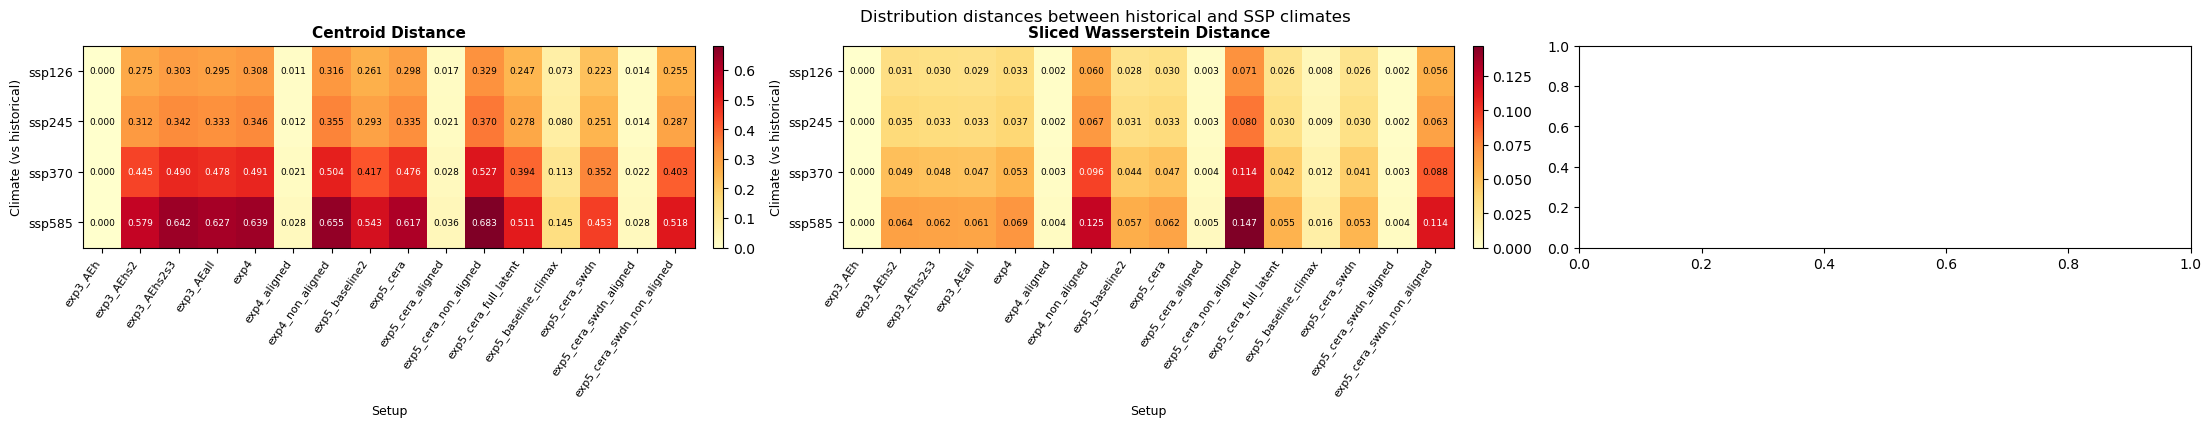

In [ ]:
distance_metrics = [
    ("centroid_distance",  "Centroid Distance"),
    ("sliced_wasserstein", "Sliced Wasserstein Distance"),
]
setup_order = [s for s in SETUPS.keys() if s in dist_df["setup"].values]

# ── Summary table (all three metrics concatenated) ─────────────────────────────
table_parts = []
for metric_key, metric_label in distance_metrics:
    pivot = (
        dist_df.pivot(index="climate", columns="setup", values=metric_key)
        .loc[target_climates, setup_order]
    )
    pivot.index = pd.MultiIndex.from_tuples(
        [(metric_label, c) for c in pivot.index]
    )
    table_parts.append(pivot)

summary_table = pd.concat(table_parts)
display(
    summary_table.style
    .format("{:.4f}")
    .background_gradient(axis=1, cmap="YlOrRd")
    .set_caption("Distances (historical → SSP) in normalised latent space — by setup (columns)")
    .set_table_styles([
        {"selector": "caption", "props": [("font-size", "14px"), ("font-weight", "bold")]},
        {"selector": "th",      "props": [("font-size", "11px")]},
    ])
)

# ── Heatmaps: one per distance metric ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(22, 4), constrained_layout=True)

for ax, (metric_key, metric_label) in zip(axes, distance_metrics):
    pivot = (
        dist_df.pivot(index="climate", columns="setup", values=metric_key)
        .loc[target_climates, setup_order]
    )
    vmax = pivot.values.max()
    im = ax.imshow(pivot.values, cmap="YlOrRd", aspect="auto", vmin=0, vmax=vmax)
    plt.colorbar(im, ax=ax, fraction=0.03, pad=0.03)

    ax.set_xticks(range(len(setup_order)))
    ax.set_xticklabels(setup_order, rotation=55, ha="right", fontsize=8)
    ax.set_yticks(range(len(target_climates)))
    ax.set_yticklabels(target_climates, fontsize=9)
    ax.set_title(metric_label, fontsize=11, fontweight="bold")
    ax.set_xlabel("Setup", fontsize=9)
    ax.set_ylabel("Climate (vs historical)", fontsize=9)

    for i, climate in enumerate(target_climates):
        for j, setup in enumerate(setup_order):
            val = pivot.loc[climate, setup]
            txt_color = "white" if val > 0.65 * vmax else "black"
            ax.text(j, i, f"{val:.3f}", ha="center", va="center",
                    fontsize=6.5, color=txt_color)

fig.suptitle(
    "Distribution distances between historical and SSP climates\n",
    fontsize=12, y=1.03
)
plt.show()